## Import

In [1]:
import numpy as np
import scipy
from scipy import signal
from scipy.signal import hilbert
from scipy import integrate

try:
    from scipy.integrate import simps
except ImportError:
    from scipy.integrate import simpson

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

os.makedirs("ims", exist_ok=True)
# os.makedirs("ims/current", exist_ok=True)
os.makedirs("ims/all", exist_ok=True)

# VERY CAREFULLY not to delete other folders!
if os.path.isdir("all_data"):
    shutil.rmtree("all_data")
    print("The all_data folder is deleted and created again")
    print(" ")

os.makedirs("all_data", exist_ok=True)

os.makedirs("all_data/inputs", exist_ok=True)

os.makedirs("all_data/current_energy", exist_ok=True)
os.makedirs("all_data/current_energy/data", exist_ok=True)
os.makedirs("all_data/current_energy/ims", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current", exist_ok=True)

os.makedirs("all_data/current_energy/ims/all/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all/pdf", exist_ok=True)

os.makedirs("all_data/current_energy/ims/energy_current/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current/pdf", exist_ok=True)



os.makedirs("all_data/hhg", exist_ok=True)
os.makedirs("all_data/hhg/data", exist_ok=True)
os.makedirs("all_data/hhg/ims", exist_ok=True)
os.makedirs("all_data/hhg/ims/png", exist_ok=True)
os.makedirs("all_data/hhg/ims/pdf", exist_ok=True)

os.makedirs("all_data/nonlinear", exist_ok=True)

os.makedirs("all_data/drude", exist_ok=True)
os.makedirs("all_data/drude/data", exist_ok=True)
os.makedirs("all_data/drude/data/current", exist_ok=True)
os.makedirs("all_data/drude/data/m", exist_ok=True)
os.makedirs("all_data/drude/data/abc", exist_ok=True)
os.makedirs("all_data/drude/data/tau", exist_ok=True)
os.makedirs("all_data/drude/data/n_ex", exist_ok=True)
os.makedirs("all_data/drude/ims", exist_ok=True)

os.makedirs("all_data/drude/ims/png", exist_ok=True)
os.makedirs("all_data/drude/ims/pdf", exist_ok=True)

os.makedirs("all_data/fid", exist_ok=True)
os.makedirs("all_data/fid/z", exist_ok=True)
os.makedirs("all_data/fid/z/data", exist_ok=True)
os.makedirs("all_data/fid/z/ims", exist_ok=True)
os.makedirs("all_data/fid/z/ims/png", exist_ok=True)
os.makedirs("all_data/fid/z/ims/pdf", exist_ok=True)


volume = 160.1 # для Si в A^3

# m0_cut_1 = 10500  # 21 fs: for exp fit
# m0_cut_2 = 6250   # 12.5 fs: for full drude fit (needs to be adjusted in accordance to z_pump energy)
# # 3749 (7.5 fms), 5999 (12 fms)

# m0_cut_3 = 5250 # 10.5 fs: start of integration for Δk analysis. half of probe pulse duration

# In[116]:


plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg') for server (not necessary)
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())


## all plots func

In [2]:
def plot_nonlinear_response_v4(folder, ax, j):


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration

    m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)

    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )


    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']


    t = data_both['time_fs']


    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']

    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']

    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']


    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
    #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
    # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
    # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


    # Построим графики
    plt.figure(figsize=(10, 12.5))

    # Общий заголовок для всей фигуры
    plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

    # Первый график: внешнее поле по z
    plt.subplot(5, 2, 1)
    plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Pump external electric field z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # Второй график: внешнее поле по x
    plt.subplot(5, 2, 2)
    plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Probe external electric field x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # # Четвертый график: суммарный ток по z
    # plt.subplot(5, 2, 4)
    # plt.plot(t, Jm_pump_z, color='magenta')
    # plt.xlabel('Time [fs]')
    # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # plt.title('Matter current density along z, only pump')
    # plt.grid(True)

    # plt.tight_layout()





    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau 6.65)


    p0 = [0.02, 0, 20]

    try:
        popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    except RuntimeError:
        print("First fit failed, trying different initial guess...")
    
        p0_v2 = [0.05, 0, 6.65]
        popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0_v2)

    
    j0, j_final, tau_pump= popt
    j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)

    # ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 4)
    plt.plot(t, Jm_pump_z, color='m')
    if tau_pump<30:
        plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
        plt.legend()
    else: plt.plot(t_array_cut, j_fit, '--', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Matter current density along z, only pump')
    plt.grid(True)
    plt.tight_layout()



    
    



    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)

    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)

    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 3)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 5)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()


    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 6)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Δ energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Суммарный ток по x
    plt.subplot(5, 2, 7)
    plt.plot(t, Jm_both_x, color='#DC143C')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along x')
    plt.grid(True)
    plt.tight_layout()
    
    
    
    
    delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x

    
    t_array_cut = np.array(t[m0_cut_1:])[::50]
    j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau= popt
    j_fit = drude_current_v1(0, j0, j_final, tau)

    ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 8)
    plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
    plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along x')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()




    # Суммарный ток по y
    plt.subplot(5, 2, 9)
    plt.plot(t, Jm_both_y, color='#00BFFF')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along y')
    plt.grid(True)
    plt.tight_layout()


    # Разностный ток по y
    plt.subplot(5, 2, 10)
    plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along y')
    plt.grid(True)
    plt.tight_layout()





    # lr_data = pd.read_csv(
    #     folder + '/lr_response.data',
    #     comment='#',
    #     delim_whitespace=True,
    #     header=None
    # )

    # lr_data.columns = [
    #     'Energy',        # 1
    #     'Re_sigma_x',    # 2
    #     'Re_sigma_y',    # 3
    #     'Re_sigma_z',    # 4
    #     'Im_sigma_x',    # 5
    #     'Im_sigma_y',    # 6
    #     'Im_sigma_z',    # 7
    #     'Re_eps_x',      # 8
    #     'Re_eps_y',      # 9
    #     'Re_eps_z',      # 10
    #     'Im_eps_x',      # 11
    #     'Im_eps_y',      # 12
    #     'Im_eps_z',      # 13
    # ]


    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 9)
    # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Im(ε)')
    # plt.title('Absorption')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()

    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 10)
    # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Re(ε)')
    # plt.title('Dispersion')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()
    # # plt.show()

    # plt.savefig("ims/all/" + folder + ".pdf")
    plt.savefig("all_data/current_energy/ims/all/png/" + str(j)+ '_current_energy_all_plots_' + folder + ".png", dpi=200)
    plt.savefig("all_data/current_energy/ims/all/pdf/" + str(j)+ '_current_energy_all_plots_' + folder + ".pdf", bbox_inches="tight")

    dt = np.diff(t, prepend=t[0])

    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    plt.show()
    plt.close()

    return tau


# In[ ]:


## exp fit drude funcs

In [3]:
def drude_current_v1(dummy_t, j0, j_final, tau):

    # tau = 6.65
    dt = 0.002

    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_1 = int(500*t_probe)

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_1:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

In [4]:
def drude_exp_fit_v2_pump(dummy_t, j0, j_final, tau):


    t_probe, t_pump = get_pulse_durations(folder)
    # m0_cut_4 = int(500*(t_probe+t_pump)/2) 
    
    # tau = 6.65
    dt = 0.002

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_4:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

## extract

In [5]:
def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

# def extract_a_num(s):
#     start = s.index('_a') + 2
#     end = s.index('_', start)
#     return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return float(match.group(1).replace("d", "e"))

def extract_amorphous_value(name):
    tokens = name.split("_")
    for i, token in enumerate(tokens):
        if token == "amorphous" and i + 1 < len(tokens):
            return float(tokens[i + 1])

In [6]:
def get_n_excited_electrons(folder):

    output_probe = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/probe_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_probe = nelec[-1]

    output_pump = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/pump_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_pump = nelec[-1]


    output_both = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/both_pulses_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_both = nelec[-1]


    
    gs_file = glob.glob(folder + '/Si_gs*')

    with open(gs_file[0], 'r') as file:
        lines = file.readlines()
    
    for line in lines:
        if 'al(1:3)' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            factor = nums[0]*nums[1]*nums[2]

    return output_both/factor, output_pump/factor, output_probe/factor

In [7]:
def get_pulse_durations(folder):

    pulses_file = glob.glob(folder + '/Si_rt_both*')
    
    with open(pulses_file[0], 'r') as file:
            lines = file.readlines()
        
    for line in lines:
        if 'tw1' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_probe = nums[0]
    
    for line in lines:
        if 'tw2' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_pump = nums[0]

    return t_probe, t_pump

## sorted folders

In [8]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
folders = [f for f in folders 
           if f.startswith('c') 
           and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data'))]
           # and not os.path.isdir(os.path.join(f, 'restart'))]


# print(folders)


if "amorphous" in folders[0]:
    sorted_folders = sorted(folders, key=extract_amorphous_value, reverse=True)

else:
    sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_i_num(s)))

print("Sorted folders are:")
for f in sorted_folders:
    print(f)
print(" ")

Sorted folders are:
c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV
 


## all plots

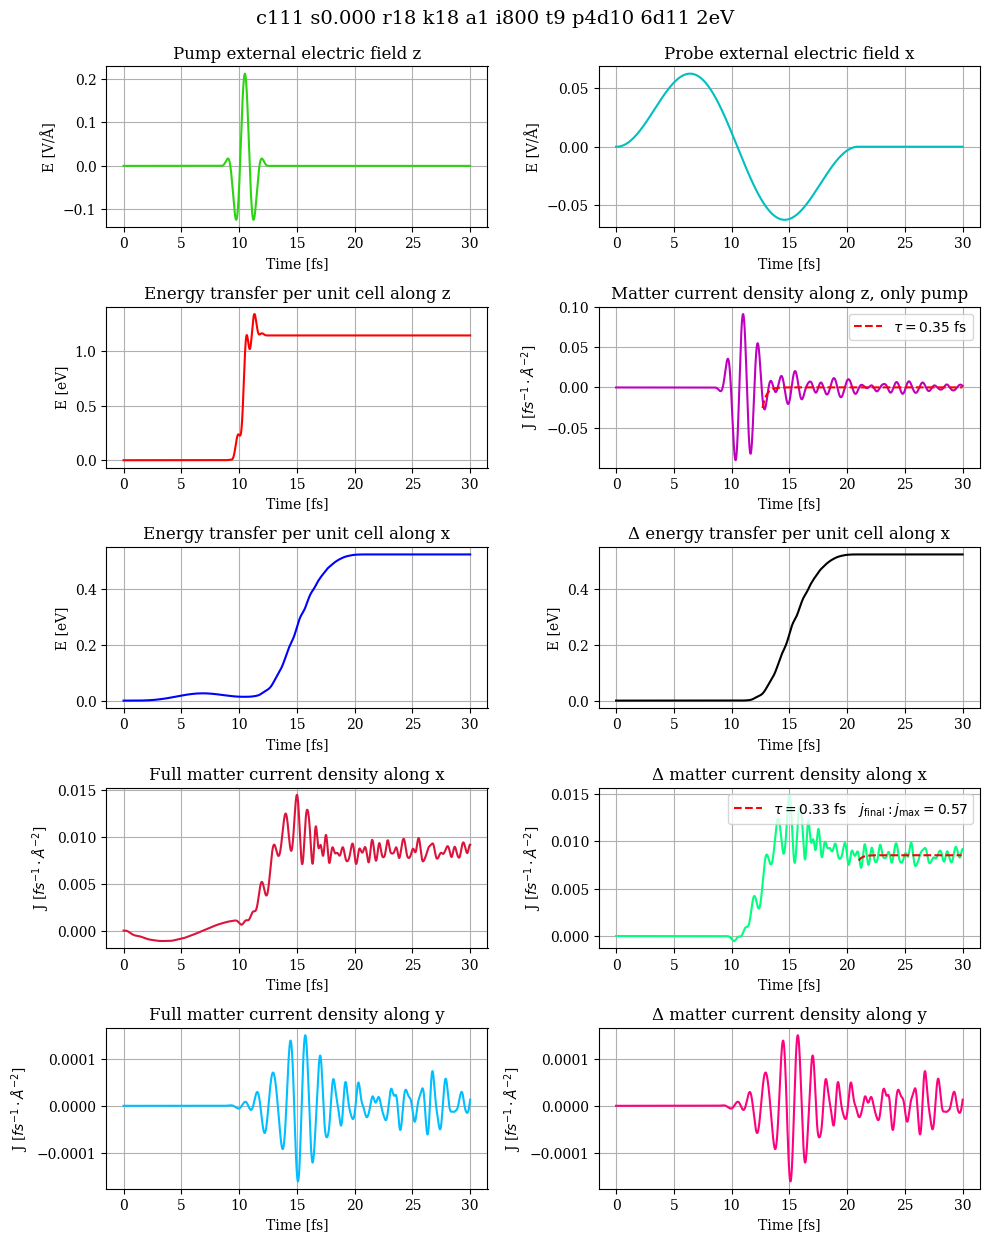

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV all plots for current&energy are completed
 


In [9]:
taus_exp_x = []

j=0
for folder in sorted_folders:
    j=j+1

    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
    tau = plot_nonlinear_response_v4(folder, ax, j)
    taus_exp_x.append(tau)
    print("For " + folder + " all plots for current&energy are completed")

print(" ")

## energy & current plots

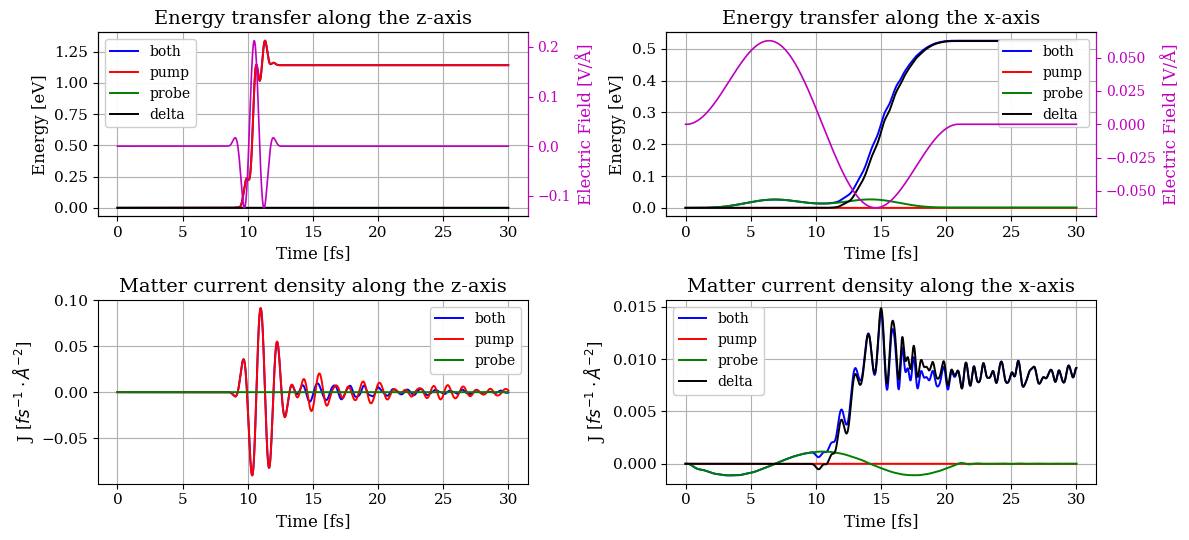

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV energy&current plots are completed
 


In [10]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)
    
    product_pump_z = El_f_pump_z * Jm_pump_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_z = np.cumsum(product_pump_z * dt)
    
    product_probe_z = El_f_pump_z * Jm_probe_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_z = np.cumsum(product_probe_z * dt)
    
    product_delta_z = El_f_pump_z * (Jm_both_z - Jm_pump_z - Jm_probe_z) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_z = np.cumsum(product_delta_z * dt)
    
    
    
    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)
    
    product_pump_x = El_f_probe_x * Jm_pump_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_x = np.cumsum(product_pump_x * dt)
    
    product_probe_x = El_f_probe_x * Jm_probe_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_x = np.cumsum(product_probe_x * dt)
    
    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)
    
    
    
    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 5.5))

    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=11)
    
    line_w=1.4
    alpha_val=1
    color_field = color = mcolors.to_rgba("m", alpha=alpha_val)
    framealpha_val=0.95
    
    ax1 = axs[0][1]
    
    ax1.plot(t, -integral_both_x, color='b', label='both', linewidth=line_w)
    ax1.plot(t, -integral_pump_x, color='r', label='pump', linewidth=line_w)
    ax1.plot(t, -integral_probe_x, color='green', label='probe', linewidth=line_w)
    ax1.plot(t, -integral_delta_x, color='black', label='delta', linewidth=line_w)
    ax1.set_xlabel('Time [fs]', fontsize=12)
    ax1.set_ylabel('Energy [eV]', fontsize=12)
    ax1.set_title('Energy transfer along the x-axis', fontsize=14)
    ax1.legend(loc="upper right", framealpha=framealpha_val)
    ax1.grid()
    plt.tight_layout()
    
    
    ax1_right = ax1.twinx()
    ax1_right.plot(t, El_f_probe_x, color=color_field, label='probe field', linewidth=1.2)
    ax1_right.set_ylabel("Electric Field [V/Å]", color=color_field, fontsize=12)
    ax1_right.tick_params(axis="y", colors=color_field)
    ax1_right.spines["right"].set_color(color_field)
    # ax1_right.legend()
    plt.tight_layout()
    
    
    
    ax2 = axs[0][0]
    
    ax2.plot(t, -integral_both_z, color='b', label='both', linewidth=line_w)
    ax2.plot(t, -integral_pump_z, color='r', label='pump', linewidth=line_w)
    ax2.plot(t, -integral_probe_z, color='green', label='probe', linewidth=line_w)
    ax2.plot(t, -integral_delta_z, color='black', label='delta', linewidth=line_w)
    ax2.set_xlabel('Time [fs]', fontsize=12)
    ax2.set_ylabel('Energy [eV]', fontsize=12)
    ax2.set_title('Energy transfer along the z-axis', fontsize=14)
    ax2.legend(framealpha=framealpha_val)
    ax2.grid()
    plt.tight_layout()
    
    
    ax2_right = ax2.twinx()
    ax2_right.plot(t, El_f_pump_z, color=color_field, label='probe field', linewidth=1.2)
    ax2_right.set_ylabel("Electric Field [V/Å]", color=color_field, fontsize=12)
    ax2_right.tick_params(axis="y", colors=color_field)
    ax2_right.spines["right"].set_color(color_field)
    # ax1_right.legend()
    plt.tight_layout()
    
    
    
    ax3 = axs[1][0]
    
    ax3.plot(t, Jm_both_z, color='b', label='both', linewidth=line_w)
    ax3.plot(t, Jm_pump_z, color='r', label='pump', linewidth=line_w)
    ax3.plot(t, Jm_probe_z, color='green', label='probe', linewidth=line_w)
    # ax3.plot(t, -integral_delta_z, color='black', label='delta')
    ax3.set_xlabel('Time [fs]', fontsize=12)
    ax3.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]', fontsize=12)
    ax3.set_title('Matter current density along the z-axis', fontsize=14)
    ax3.legend(framealpha=framealpha_val)
    ax3.grid()
    plt.tight_layout()
    
    
    # ax3_right = ax3.twinx()
    # ax3_right.plot(t, -El_f_pump_z, color='m', label='probe field')
    # ax3_right.set_ylabel("—Electric Field [V/Å]", color='m')
    # ax3_right.tick_params(axis="y", colors='m')
    # ax3_right.spines["right"].set_color('m')
    # # ax1_right.legend()
    # plt.tight_layout()
    
    
    
    ax4 = axs[1][1]
    
    ax4.plot(t, Jm_both_x, color='b', label='both', linewidth=line_w)
    ax4.plot(t, Jm_pump_x, color='r', label='pump', linewidth=line_w)
    ax4.plot(t, Jm_probe_x, color='green', label='probe', linewidth=line_w)
    ax4.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta', linewidth=line_w)
    ax4.set_xlabel('Time [fs]', fontsize=12)
    ax4.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]', fontsize=12)
    ax4.set_title('Matter current density along the x-axis', fontsize=14)
    ax4.legend(framealpha=framealpha_val)
    ax4.grid()
    plt.tight_layout()
    
    # ax4_right = ax4.twinx()
    # ax4_right.plot(t, -El_f_pump_z, color='m', label='probe field')
    # ax4_right.set_ylabel("—Electric Field [V/Å]", color='m')
    # ax4_right.tick_params(axis="y", colors='m')
    # ax4_right.spines["right"].set_color('m')
    # # ax1_right.legend()
    # plt.tight_layout()
    
    
    
    plt.savefig("all_data/current_energy/ims/energy_current/png/" + str(j)+ '_energy_current_' + folder + ".png", dpi=200)
    plt.savefig("all_data/current_energy/ims/energy_current/pdf/" + str(j)+ '_energy_current_' + folder + ".pdf", bbox_inches="tight")

    plt.show()
    plt.close()

    print("For " + folder + " energy&current plots are completed")

print(" ")

## current & energy data

In [11]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)
    
    product_pump_z = El_f_pump_z * Jm_pump_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_z = np.cumsum(product_pump_z * dt)
    
    product_probe_z = El_f_pump_z * Jm_probe_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_z = np.cumsum(product_probe_z * dt)
    
    product_delta_z = El_f_pump_z * (Jm_both_z - Jm_pump_z - Jm_probe_z) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_z = np.cumsum(product_delta_z * dt)
    
    
    
    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)
    
    product_pump_x = El_f_probe_x * Jm_pump_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_x = np.cumsum(product_pump_x * dt)
    
    product_probe_x = El_f_probe_x * Jm_probe_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_x = np.cumsum(product_probe_x * dt)
    
    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)
    
    
    
    
    
    each_num=10
    
    current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
                                    Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
                                    Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
                                    Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num], 
                                    -integral_both_z[::each_num], -integral_pump_z[::each_num], -integral_probe_z[::each_num],
                                    -integral_both_x[::each_num], -integral_pump_x[::each_num], -integral_probe_x[::each_num]
                                    ])
    
    columns = ["time",  "El_f_pump_z", "El_f_probe_x",
               "Jm_both_z", "Jm_pump_z", "Jm_probe_z",
               "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
               "Jm_both_x", "Jm_pump_x", "Jm_probe_x", 
               "En_both_z", "En_pump_z", "En_probe_z", 
               "En_both_x", "En_pump_x", "En_probe_x"]
    df = pd.DataFrame(current_energy_array.T, columns=columns)
    
    
    df.to_csv("all_data/current_energy/data/" + str(j)+ "_current_energy_data_" + folder + ".csv", index=False)
    
    with open("all_data/current_energy/data/" + str(j)+ "_current_energy_data_" + folder + ".csv", "w") as f:
        f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " current&energy data saving in csv format is completed")

print(" ")
    # df_read = pd.read_csv("current_data.csv", comment="#")
    # df_read
    
    # plt.savefig("all_data/current_energy/ims/energy_current/png/" + str(j)+ '_' + folder + ".png", dpi=200)

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV current&energy data saving in csv format is completed
 


## hhg plots

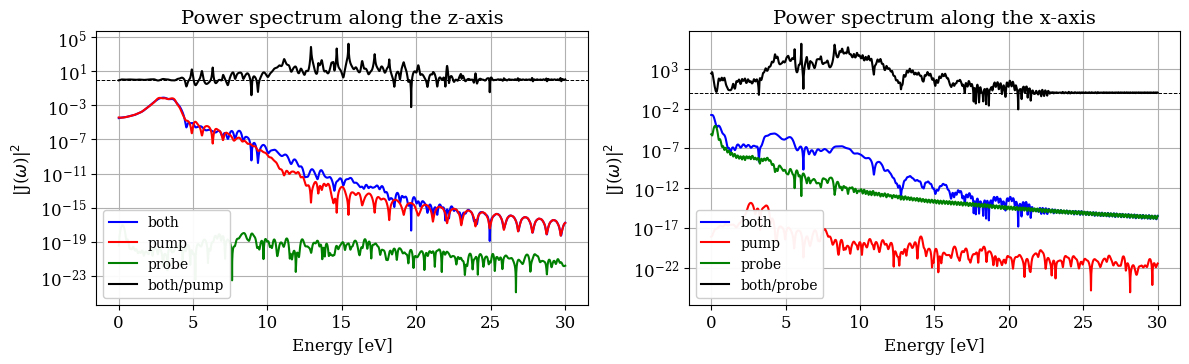

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV hhg plots are completed
 


In [12]:
j=0
for folder in sorted_folders:
    
    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    pulse_data_both = pd.read_csv(
        folder + '/both_pulses_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_pump = pd.read_csv(
        folder + '/pump_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_probe = pd.read_csv(
        folder + '/probe_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    pulse_data_both.columns = [
        'Energy_eV',
    
        'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
        'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
        'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',
    
        'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
        'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
        'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',
    
        'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
        'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
        'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
    ]
    
    pulse_data_pump.columns  = pulse_data_both.columns
    
    pulse_data_probe.columns = pulse_data_both.columns
    
    
    energies = pulse_data_both['Energy_eV']
    
    
    Abs2_Jm_both_z  =  pulse_data_both['Abs2_Jm_z']
    Abs2_Jm_pump_z  =  pulse_data_pump['Abs2_Jm_z']
    Abs2_Jm_probe_z =  pulse_data_probe['Abs2_Jm_z']
    
    Abs2_Jm_both_x  =  pulse_data_both['Abs2_Jm_x']
    Abs2_Jm_pump_x  =  pulse_data_pump['Abs2_Jm_x']
    Abs2_Jm_probe_x =  pulse_data_probe['Abs2_Jm_x']
    
    Abs2_Jm_both_y  =  pulse_data_both['Abs2_Jm_y']
    Abs2_Jm_pump_y  =  pulse_data_pump['Abs2_Jm_y']
    Abs2_Jm_probe_y =  pulse_data_probe['Abs2_Jm_y']
    
    
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.75))
    
    line_w=1.5
    alpha_val=1
    color_field = color = mcolors.to_rgba("m", alpha=alpha_val)
    framealpha_val=0.95
    
    ax1 = axs[0]
    
    
    ax1.axhline(y=1.0, color='black', linestyle='--', linewidth=0.7)
    
    ax1.plot(energies, Abs2_Jm_both_z, color='b', label='both', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_pump_z, color='r', label='pump', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_probe_z, color='green', label='probe', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_both_z/Abs2_Jm_pump_z, color='black', label='both/pump', linewidth=line_w)
    ax1.set_xlabel('Energy [eV]', fontsize=12)
    ax1.set_ylabel(r'|J($\omega$)|$^2$', fontsize=12)
    ax1.set_title('Power spectrum along the z-axis', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    ax1.legend(loc="lower left", framealpha=framealpha_val, fontsize=10)
    ax1.set_yscale('log')
    ax1.grid()
    plt.tight_layout()
    
    
    
    ax2 = axs[1]

    ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=0.7)
    
    ax2.plot(energies, Abs2_Jm_both_x, color='b', label='both', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_pump_x, color='r', label='pump', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_probe_x, color='green', label='probe', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_both_x/Abs2_Jm_probe_x, color='black', label='both/probe', linewidth=line_w)
    # ax2.plot(energies, Abs2_Jm_both_z/Abs2_Jm_pump_z, color='black', label='both/pump', linewidth=line_w)
    ax2.set_xlabel('Energy [eV]', fontsize=12)
    ax2.set_ylabel(r'|J($\omega$)|$^2$', fontsize=12)
    ax2.set_title('Power spectrum along the x-axis', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(loc="lower left", framealpha=framealpha_val)
    ax2.set_yscale('log')
    ax2.grid()
    plt.tight_layout()
    
    
    plt.savefig("all_data/hhg/ims/png/" + str(j)+ '_hhg_' + folder + ".png", dpi=200)
    plt.savefig("all_data/hhg/ims/pdf/" + str(j)+ '_hhg_' + folder + ".pdf", bbox_inches="tight")

    plt.show()
    plt.close()
    
    print("For " + folder + " hhg plots are completed")

print(" ")

## hhg data

In [13]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    pulse_data_both = pd.read_csv(
        folder + '/both_pulses_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_pump = pd.read_csv(
        folder + '/pump_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_probe = pd.read_csv(
        folder + '/probe_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    pulse_data_both.columns = [
        'Energy_eV',
    
        'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
        'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
        'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',
    
        'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
        'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
        'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',
    
        'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
        'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
        'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
    ]
    
    pulse_data_pump.columns  = pulse_data_both.columns
    
    pulse_data_probe.columns = pulse_data_both.columns
    
    
    #both
    pulse_data_both_cut = pulse_data_both[pulse_data_both.columns[:10]]
    pulse_data_both_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_both_pulses_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_both_pulses_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_both_cut.to_csv(f, index=False)
    
    
    #pump
    pulse_data_pump_cut = pulse_data_pump[pulse_data_pump.columns[:10]]
    pulse_data_pump_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_pump_pulse_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_pump_pulse_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_pump_cut.to_csv(f, index=False)
    
    
    #probe
    pulse_data_probe_cut = pulse_data_probe[pulse_data_probe.columns[:10]]
    pulse_data_probe_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_probe_pulse_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_probe_pulse_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_probe_cut.to_csv(f, index=False)
    
    
    print("For " + folder + " hhg csv data saving is completed")

print(" ")

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV hhg csv data saving is completed
 


## drude

In [14]:
def effecive_mass_model(alpha, a, b, c):
    return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [15]:
delta_start_drude_fit = 3400

def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    t = data_both['time_fs']
    El_f_probe_x = data_both['E_ext_x']
    
    
    step_dt = 0.002
    


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    
    
    dt = np.diff(t, prepend=t[0])
    
    
    alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
    fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
    alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_2:])         # сетка времени
    E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0

    # if folder=='c333_amorphous_0.93_s0.050_r18_k16_a1_i804_t9_p4d10_2d11':
    #     for k in range(len(t_array)-1):
    #         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/5 + alpha_fit[k] * E_array[k])

    # else: 
    #     for k in range(len(t_array)-1):
    #         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
    for k in range(len(t_array)-1):
            j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])
    
    return j_euler[::1]

0.003762128646856511 0.6185492679852342 11.706811700363472
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV drude fit plots are completed
For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV drude fit current data saving in csv format is completed


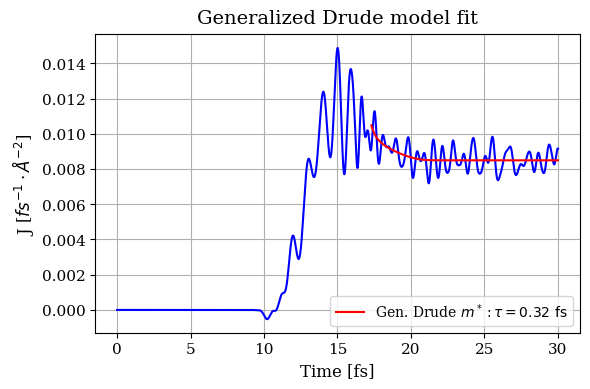

In [16]:
new_taus = []
new_j_finals = []
arr_abc = []

alphas_start = []
alphas_final = []

    
folder = sorted_folders[0]

j=0
num_folder=0
for folder in sorted_folders:

    j=j+1
    num_folder=num_folder+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    dt = np.diff(t, prepend=t[0])
    
    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    alphas_start.append(a_start)
    alphas_final.append(a_fin)
    
    
    # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)
    
    
    fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
    delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x
    
    # t_array_cut = np.array(t[m0_cut_2:])[::50]
    # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
    # # (dummy_t, j0, fit_alpha, j_final)
    # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
    # # print(len(t_array_cut), len(j_exp))
    # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
    # j0, fit_alpha = popt
    # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)
    
    plt.figure(figsize=(6,4))
    # plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
    plt.title("Generalized Drude model fit", fontsize=14, y=1.01)
    plt.plot(t, delta_Jm_x, color='b')
    # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
    plt.xlabel("Time [fs]", fontsize=12)
    plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    
    
    t_array_cut = np.array(t[m0_cut_2:])[::1]
    j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
    # (dummy_t, j0, fit_alpha, j_final)
    p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
    # print(len(t_array_cut), len(j_exp))
    popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
    [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
    ))
    j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
    j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)
    
    new_taus.append(fit_tau_val)
    new_j_finals.append(fit_j_fin_val)
    
    plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
    plt.legend(fontsize=10)
    plt.grid()
    arr_abc.append((a, b, c))
    print(a, b, c)

    plt.tight_layout()

    plt.savefig("all_data/drude/ims/png/" + str(j)+ '_drude_fit_' + folder + ".png", dpi=200)
    plt.savefig("all_data/drude/ims/pdf/" + str(j)+ '_drude_fit_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " drude fit plots are completed")




    j_fit_extended = np.concatenate(([None]*m0_cut_2, j_fit))
    
    drude_current_arr=np.array([t, delta_Jm_x, j_fit_extended])

    columns = ["time",  "delta_Jm_x", "delta_Jm_x_drude_fit"]
    df = pd.DataFrame(drude_current_arr.T, columns=columns)
    
    
    df.to_csv("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", index=False)
    
    with open("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", "w") as f:
        f.write(r"# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " drude fit current data saving in csv format is completed")

    plt.show()
    plt.close()

    


print(" ")

In [17]:
def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

Effective mass plots are completed
 


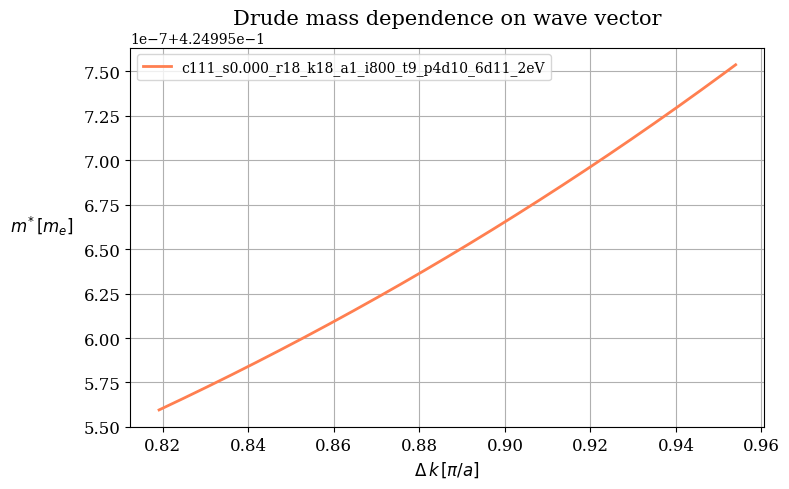

In [18]:

# colors = blue_red_gradient(len(sorted_folders))
colors=['coral', 'b', 'r', 'm', 'g', 'orange', 'gold', 'purple', 'slateblue', 'olive', 'navy', 'darkred']

if len(sorted_folders)<12:


    plt.figure(figsize=(8,5))
    plt.title("Drude mass dependence on wave vector", fontsize=15)
    
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    
    plot_part=1
    num_folder=0
    for (a0, b0, c0) in arr_abc:
        num_folder+=1
        if num_folder!=0:
            plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), 
            [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
            plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2, color=colors[num_folder-1])

    j=j+1
    plt.grid()
    plt.legend()
    plt.xlabel(r'$\Delta \, k \, [\pi/a]$', fontsize=12)
    # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
    # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
    plt.ylabel(r'$m^{*}\, [m_e]$', fontsize=12, rotation=0,  labelpad=30)
    plt.tight_layout()
    
    plt.savefig("all_data/drude/ims/png/" + 'drude_m_dependence.png', dpi=200)
    plt.savefig("all_data/drude/ims/pdf/" + 'drude_m_dependence.pdf', bbox_inches="tight")

    print("Effective mass plots are completed")
    print(" ")

    plt.show()
    plt.close()


    
    # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

In [19]:
num_folder=0
for (a0, b0, c0) in arr_abc:
    num_folder+=1

    plot_part=1
    
    delta_k_vals = np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)
    
    effective_mass_vals = [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
    plot_part*alphas_final[num_folder-1], 500)]
    
    effective_mass_data=np.array([delta_k_vals, effective_mass_vals])

    columns = ["delta_k",  "effective_mass"]
    df = pd.DataFrame(effective_mass_data.T, columns=columns)
    
    
    df.to_csv("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", index=False)
    
    with open("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", "w") as f:
        f.write(r"# Units: Wave vector during the probe pulse $\Delta k$ [$\pi/a$], Effective mass $m^{*}$ [$m_e$]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + sorted_folders[num_folder-1] + " effective mass data saving in csv format is completed")


print(" ")

For c111_s0.000_r18_k18_a1_i800_t9_p4d10_6d11_2eV effective mass data saving in csv format is completed
 


## fid

In [22]:
new_taus

[np.float64(0.08253440255848273)]

In [17]:
def coherence_time(Y, dt) -> float:
    r"""
    Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

    The function implements Mandel's coherence time. It calculates the autocorrelation
    function of the given signal, then it calculates the complex envelope of the
    autocorrelation function, and integrates the square of the normalized envelope from
    t=0 to the maximal time. The coherence time is twice the value of the integral.

    Args:
      Y: 1D array that represents the time-dependent signal on a regular grid.
      dt: Time step of the grid.

    Returns:
      the coherence time as a floating-point number.
    """
    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING

    try:
        return 2.0 * scipy.integrate.simps(ACF_envelope[i1:]**2, dx=dt)
    except Exception:
        return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

In [18]:
# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct") # autocorrelation function
# ACF_envelope_v2 = np.abs(hilbert(ACF))
# ACF_envelope_v2 = ACF_envelope_v2/max(ACF_envelope_v2)

# plt.plot(ACF/max(ACF))
# plt.plot(ACF_envelope_v2)

In [19]:
# coherence_time(fid_signal, 0.002)
# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct") # autocorrelation function
# ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
# ACF_envelope /= np.max(ACF_envelope)

# plt.plot(abs(ACF)/max(ACF))
# plt.plot(ACF_envelope)

In [20]:
def get_autocorr_envelope(Y, dt):

    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(hilbert(ACF))
    # ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING
    
    return ACF_envelope[i1:]

In [21]:
def coherence_time_v2_abs(Y, dt) -> float:
    # autocorrelation of abs of the signal and then Mandel's integration
    ACF = scipy.signal.correlate(abs(Y), abs(Y), mode="full", method="direct") # autocorrelation function
    ACF = ACF/max(ACF)
    N = len(Y)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    
    try:
        return 2.0 * scipy.integrate.simps(ACF[i1:]**2, dx=dt)
    except Exception:
        # print("No scipy.integrate.simps function")
        return 2.0 * scipy.integrate.simpson(ACF[i1:]**2, dx=dt)

In [22]:
def find_halfcycle_maxima(t, y):
    """
    Находит координаты всех локальных максимумов:
    y'(t)=0 и y''(t)<0
    Возвращает массивы t_max, y_max
    """
    
    # первая и вторая производные
    dy = np.gradient(y, t)
    d2y = np.gradient(dy, t)

    # условие смены знака производной + на -
    sign_change = np.where(
        (dy[:-1] > 0) & (dy[1:] <= 0)
    )[0]

    # фильтрация по второй производной < 0
    maxima_indices = [
        i for i in sign_change if d2y[i] < 0
    ]

    t_max = t[maxima_indices]
    y_max = y[maxima_indices]

    return np.array(t_max), np.array(y_max)

In [23]:
def exp_gauss(t, A, tau, t0, sigma, C):
    return A * np.exp(-t / new_taus[j-1]) * np.exp(-(0*t)**2 / (2 * sigma**2)) + C**2


def fit_exp_gauss(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    A0 = np.max(y) - np.min(y)
    tau0 = 2
    t0_0 = 0
    sigma0 = 1
    C0 = np.min(y)

    p0 = [A0, tau0, t0_0, sigma0, C0]

    popt, pcov = curve_fit(exp_gauss, t, y, p0=p0, maxfev=10000)

    return popt, pcov

In [24]:
def gaussian_convolve(y, sigma):
    """
    Свёртка массива y с гауссовым ядром.
    
    sigma — стандартное отклонение в точках.
    """
    y = np.asarray(y)
    
    # длина ядра (берём ±4σ)
    radius = int(4 * sigma)
    x = np.arange(-radius, radius + 1)
    
    # гауссово ядро
    kernel = np.exp(-x**2 / (2 * sigma**2))
    kernel /= kernel.sum()  # нормировка
    
    # линейная свёртка (без периодичности)
    y_smooth = np.convolve(y, kernel, mode='same')
    
    return y_smooth

In [25]:
def fourier_plot(fid_signal, convolve_val):

    N = len(fid_signal)
    
    # убираем среднее (рекомендовано)
    x = np.array(fid_signal)-np.mean(fid_signal)
    
    # FFT
    M=5
    xpad = np.pad(x, (0, (M-1)*len(x)))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs
    
    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696                # eV·fs
    E_eV = h_eV_fs * freq
    
    # амплитуда
    A = np.abs(X)
    
    # график
    # plt.plot(E_eV, gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val)), color='b')
    # plt.xlabel("Energy (eV)")
    # plt.ylabel("|FFT|")
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)
    # plt.grid()
    # plt.show()
    A = A[:int(110*M/4)]

    return E_eV[:int(110*M/4)], gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val))

In [100]:
def apply_window(fid_signal, window="hann", tukey_alpha=0.5):
    x = np.asarray(fid_signal, dtype=float)
    N = len(x)

    if window == "hann":
        w = np.hanning(N)
    elif window == "hamming":
        w = np.hamming(N)
    elif window == "blackman":
        w = np.blackman(N)
    elif window == "tukey":
        # Tukey: alpha=0 -> прямоугольное, alpha=1 -> Hann
        a = float(tukey_alpha)
        n = np.arange(N)
        w = np.ones(N)
        if a > 0:
            edge = int(np.floor(a * (N - 1) / 2))
            if edge > 0:
                # левый край
                w[:edge] = 0.5 * (1 + np.cos(np.pi * (2*n[:edge]/(a*(N-1)) - 1)))
                # правый край
                k = n[-edge:]
                w[-edge:] = 0.5 * (1 + np.cos(np.pi * (2*k/(a*(N-1)) - 2/a + 1)))
    else:
        raise ValueError("Unknown window type")

    x_windowed = (x - np.mean(x)) * w  # убираем DC и применяем окно
    
    # компенсация средней потери амплитуды
    x_windowed /= np.mean(w)

    return x_windowed

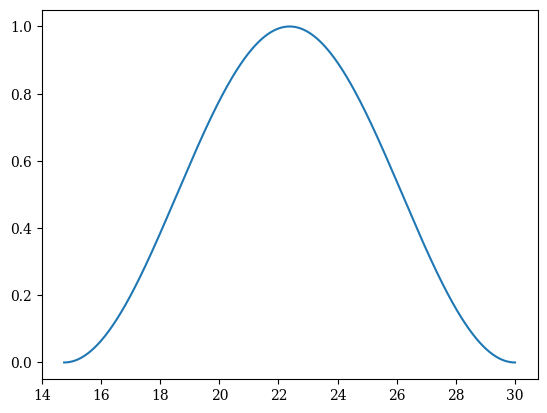

In [108]:
# plt.plot(t[m0_cut_4:], fid_signal)
plt.plot(t[m0_cut_4:], apply_window(fid_signal, window="tukey", tukey_alpha=1))

# plt.plot(t[m0_cut_4:], apply_window(fid_signal, window="hamming"))
# plt.plot(t[m0_cut_4:], apply_window(fid_signal, window="blackman"))

In [157]:
def fourier_plot_window(fid_signal, convolve_val, dt=0.002, M=5, window="hann", tukey_alpha=0.2):
    N = len(fid_signal)

    # убираем среднее (рекомендовано)
    x = np.asarray(fid_signal, dtype=float) - np.mean(fid_signal)

    # --- мягкое окно ---
    if window is None or window == "none":
        w = np.ones(N)
    elif window == "hann":
        w = np.hanning(N)
    elif window == "hamming":
        w = np.hamming(N)
    elif window == "blackman":
        w = np.blackman(N)
    elif window == "tukey":
        # Tukey: alpha=0 -> прямоугольное, alpha=1 -> Hann
        a = float(tukey_alpha)
        n = np.arange(N)
        w = np.ones(N)
        if a > 0:
            edge = int(np.floor(a * (N - 1) / 2))
            if edge > 0:
                # левый край
                w[:edge] = 0.5 * (1 + np.cos(np.pi * (2*n[:edge]/(a*(N-1)) - 1)))
                # правый край
                k = n[-edge:]
                w[-edge:] = 0.5 * (1 + np.cos(np.pi * (2*k/(a*(N-1)) - 2/a + 1)))
    else:
        raise ValueError(f"Unknown window: {window}")

    xw = x * w

    # (опционально) компенсация потери амплитуды из-за окна
    # чтобы уровень спектра не “просел” просто из-за окна:
    w_mean = np.mean(w)
    if w_mean > 0:
        xw = xw / w_mean

    # FFT + zero-padding
    xpad = np.pad(xw, (0, (M - 1) * N))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M * N, d=dt)   # 1/fs

    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696  # eV·fs
    E_eV = h_eV_fs * freq

    # амплитуда
    A = np.abs(X)

    # обрезка диапазона как у тебя
    cut = int(110 * M / 4)
    A = A[:cut]
    E_eV = E_eV[:cut]

    # сглаживание/свёртка и нормировка
    A_conv = gaussian_convolve(A, convolve_val)
    A_norm = A_conv / np.max(A_conv) if np.max(A_conv) != 0 else A_conv

    return E_eV, A_norm

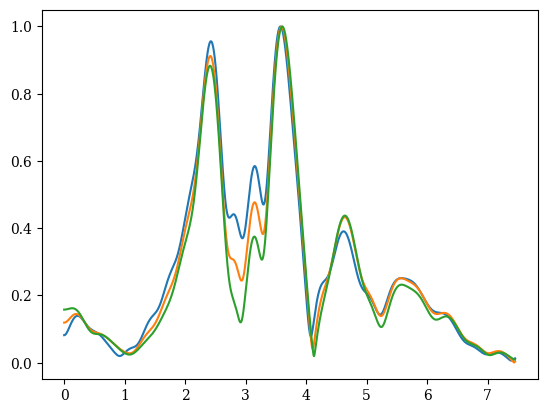

In [156]:
# ens, F_fid = fourier_plot(fid_signal, 0.1)
# plt.plot(ens, F_fid)

# ens, F_fid = fourier_plot_window(fid_signal, 0.1, window="hann")
# plt.plot(ens, F_fid)

# ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)
# plt.plot(ens, F_fid)

# ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.1)
# plt.plot(ens, F_fid)

ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)
plt.plot(ens, F_fid)

ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.4)
plt.plot(ens, F_fid)

ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.5)
plt.plot(ens, F_fid)


# ens, F_J_pump = fourier_plot_window(Jm_pump_z, 0.1, M=40, window="tukey", tukey_alpha=0.2)
# plt.plot(ens, F_J_pump)

# ens, F_fid = fourier_plot_window(fid_signal, 1, M=100, window="blackman")
# plt.plot(ens, F_fid)

In [142]:
t

0         0.002
1         0.004
2         0.006
3         0.008
4         0.010
          ...  
14995    29.992
14996    29.994
14997    29.996
14998    29.998
14999    30.000
Name: time_fs, Length: 15000, dtype: float64

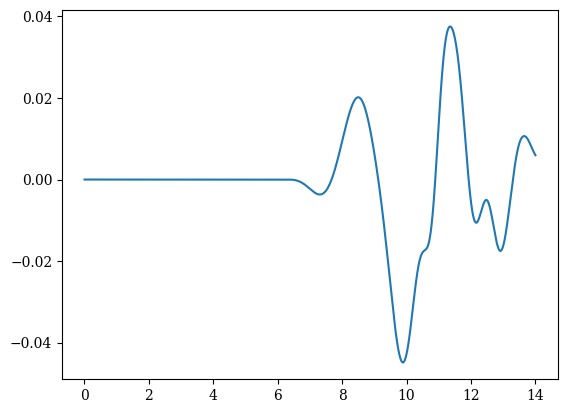

In [125]:
plt.plot(t[:7000], Jm_pump_z[:7000])

In [26]:
def moving_average_time(signal, dt, window_width, mode='reflect'):

    signal = np.asarray(signal)

    # перевод ширины окна в количество точек
    window_size = int(round(window_width / dt))
 
    kernel = np.ones(window_size) / window_size

    pad = window_size // 2
    padded = np.pad(signal, pad, mode=mode)

    avg = np.convolve(padded, kernel, mode='valid')

    return avg[1:]

In [182]:
error_min = 100

for m0_cut_4_shift in [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]:

    tau_fid_z_arr = []
    
    auto_corr_mandels_coherence=[]
    
    mandels_coherence_arr=[]
    mandels_coherence_abs_v2_arr=[]
    
    autocorr_fid_1_e_arr=[]
    autocorr_fid_1_e_abs_v2=[]
    autocorr_fid_3_e_arr=[]
    
    normalized_fid_mandels_coherence=[]
    normalized_fid_mandels_coherence_abs_v2=[]
    
    
    eV_autocorrelation_fid=[]
    eV_autocorrelation_normalized_fid=[]
    
    eV_autocorrelation_fid_coherence_v2=[]
    eV_autocorrelation_fid_normalized_coherence_v2=[]
    
    j=0
    for folder in sorted_folders:
    
        j=j+1
        
        t_probe, t_pump = get_pulse_durations(folder)
        
        m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
        m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
        
        m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
        
        m0_cut_4 = int(500*(t_probe+t_pump)/2 - m0_cut_4_shift) # pump exp fit, at the end of the pump pulse
        
        # Загрузка данных, пропуская строки с комментариями (начинаются с #)
        data_both = pd.read_csv(
            folder + '/both_pulses_rt.data',
            comment='#',
            delim_whitespace=True,
            header=None
        )
        
        data_pump = pd.read_csv(
            folder + '/pump_pulse_rt.data',
            comment='#',
            delim_whitespace=True,
            header=None
        )
        
        data_probe = pd.read_csv(
            folder + '/probe_pulse_rt.data',
            comment='#',
            delim_whitespace=True,
            header=None
        )
        
        
        # Назначим читаемые имена колонкам
        data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
            'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
            'Jm_x', 'Jm_y', 'Jm_z']
        
        data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
            'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
            'Jm_x', 'Jm_y', 'Jm_z']
        
        data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
            'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
            'Jm_x', 'Jm_y', 'Jm_z']
        
        
        t = data_both['time_fs']
        
        
        Jm_both_z  =  data_both['Jm_z']
        Jm_pump_z  =  data_pump['Jm_z']
        Jm_probe_z =  data_probe['Jm_z']
        
        Jm_both_x  =  data_both['Jm_x']
        Jm_pump_x  =  data_pump['Jm_x']
        Jm_probe_x =  data_probe['Jm_x']
        
        Jm_both_y  =  data_both['Jm_y']
        Jm_pump_y  =  data_pump['Jm_y']
        Jm_probe_y =  data_probe['Jm_y']
        
        
        El_f_pump_z = data_both['E_ext_z']
        El_f_probe_x = data_both['E_ext_x']
        
        
        
        t_array_cut = np.array(t[m0_cut_4:])[::50]
        j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
        # (dummy_t, j0, j_final, tau)
    
   
        fid_signal = Jm_pump_z[m0_cut_4:]
        
        fid_signal = fid_signal-moving_average_time(fid_signal, 0.002, 10)
            
        
        t_z_exp_fit = t[m0_cut_4:]
        # fid_z = Jm_pump_z[m0_cut_4:]-j_fit_full
        t_peaks_vals, fid_peak_vals = find_halfcycle_maxima(np.array(t_z_exp_fit), np.array(fid_signal))
        
        
        # fit peak points
        t_fit_vals = t_peaks_vals
        y_fit_vals = fid_peak_vals
        
        exclude_array=[]
        # exclude_array = [2, 3, 4]
        t_fit_vals = np.delete(t_fit_vals, exclude_array)
        y_fit_vals = np.delete(y_fit_vals, exclude_array)
    
    
        
        params, cov = fit_exp_gauss(t_fit_vals, y_fit_vals)
        
        A, tau_exp_z, t0, sigma, C = params
    
        tau_fid_z_arr.append(tau_exp_z)
        
        # print("Fit parameters:")
        # print(f"A = {A}")
        # print(f"tau = {tau_exp_z}")
        # print(f"t0 = {t0}")
        # print(f"sigma = {sigma}")
        # print(f"C = {C}")
        
        # построение
        t_fit = t_z_exp_fit
        y_fit = exp_gauss(t_fit, *params)
    
        xticks_fontsize=10
        yticks_fontsize=10
        legend_fontsize=12
        
        title_fontsize=14
        xlabel_fontsize=12
        ylabel_fontsize=12
        
        
        normalized_fid_signal=fid_signal/(y_fit+max(fid_peak_vals[-4:])-C**2)
        normalized_fid_signal = normalized_fid_signal-moving_average_time(normalized_fid_signal, 0.002, 5)
    
          
    
        # print("Mandel's time fot fid normalized signal", coherence_time(normalized_fid_signal, 0.002))
        normalized_fid_mandels_coherence.append(coherence_time(normalized_fid_signal, 0.002))
        normalized_fid_mandels_coherence_abs_v2.append(coherence_time_v2_abs(normalized_fid_signal, 0.002))
    
        
        
        each_num=5
        
    
        # print("Mandel's coherence time:", coherence_time(np.array(fid_signal), 0.002))
        mandels_coherence_arr.append(coherence_time(np.array(fid_signal), 0.002))
        mandels_coherence_abs_v2_arr.append(coherence_time_v2_abs(fid_signal, 0.002))
    
     
        auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
        auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
        auto_corr = auto_corr / auto_corr[0]  
    
        colors=['b', 'olive', 'r', 'g', 'm', 'orange', 'gold', 'purple', 'slateblue', 'navy', 'darkred']

        
        num_auto_corr_iters=10
        auto_corr_coh_vals=[]
        for i in range(num_auto_corr_iters):
        
            new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
            new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
            new_auto_corr = new_auto_corr / new_auto_corr[0]
            
            auto_corr=new_auto_corr
    
            # print(coherence_time(auto_corr, 0.002))
            
            auto_corr_coh_vals.append(coherence_time(auto_corr, 0.002))
        
            if i!=0 and i%(3)==0 and i//3 < 3:
                plt.plot(t[m0_cut_4:]-t[m0_cut_4], new_auto_corr, label= rf"autocorr. #{int(i+2)}", color=colors[int(i//3+1)])

        
        auto_corr_mandels_coherence.append(max(auto_corr_coh_vals))
        # auto_corr_mandels_coherence.append(coherence_time(auto_corr, 0.002))
    
    
        
        # second variable is convolve parameter val in eV

        
        F_ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)
    
        i_eV = int(np.where(F_ens > 0.5)[0][0])
        
        # plt.ylim(0, 1.1)
        # plt.xlim(1, E_eV[-1]/120)  
        
        F_ens, F_fid_normalized = fourier_plot_window(normalized_fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)


    
    
        spectral_intensity_data=np.array([F_ens, F_fid, F_fid_normalized])
    

    

        auto_corr = np.correlate(F_fid[i_eV:], F_fid[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
        auto_corr = auto_corr[len(F_fid[i_eV:])-1:]                 # лаги >= 0
        auto_corr = auto_corr / auto_corr[0]  
    
        i_0 = np.where(auto_corr < 0.369)[0][0]
        # print("Spectrum autocorrelation time: ")
        # print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    
        eV_autocorrelation_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
        eV_autocorrelation_fid_coherence_v2.append(coherence_time_v2_abs(F_fid[i_eV:], F_ens[1]-F_ens[0]))
    
    
        auto_corr = np.correlate(F_fid_normalized[i_eV:], F_fid_normalized[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
        auto_corr = auto_corr[len(F_fid_normalized[i_eV:])-1:]                 # лаги >= 0
        auto_corr = auto_corr / auto_corr[0]  
    
        i_0 = np.where(auto_corr < 0.369)[0][0]
        # print("Spectrum autocorrelation time: ")
        # print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])

        eV_autocorrelation_normalized_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
        eV_autocorrelation_fid_normalized_coherence_v2.append(coherence_time_v2_abs(F_fid_normalized[i_eV:], F_ens[1]-F_ens[0]))
    
    
    

        
        auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
        auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
        auto_corr = auto_corr / auto_corr[0]  
    
        
    
        i_1 = np.where(auto_corr < 0.369)[0][0]
        # print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
        
        i_2 = np.where(auto_corr < 0.05)[0][0]
        # print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])
    
        autocorr_fid_1_e_arr.append(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
    
    
        
        i_1_v2_abs = np.where(get_autocorr_envelope(np.array(fid_signal), 0.002) < 0.369)[0][0]
        # print(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
        autocorr_fid_1_e_abs_v2.append(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
        
    
        
        autocorr_fid_3_e_arr.append(  (np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])/3  )
    
        plt.close()
    

    
    
    delta_1_tau_arr = 1/np.array(new_taus)[1:5] + 1/np.array(normalized_fid_mandels_coherence)[1:5] - 1/np.array(mandels_coherence_arr)[1:5]
    print("For shift ", m0_cut_4_shift)
    print("error is: ", np.sum(abs(delta_1_tau_arr)) )

    if np.sum(abs(delta_1_tau_arr)) < error_min:
        m0_cut_4_shift_optimal = m0_cut_4_shift
        error_min = np.sum(abs(delta_1_tau_arr))

print("Optimal shift is ", m0_cut_4_shift_optimal)
print("with error ", error_min)
print(" ")

For shift  0
error is:  0.09986101870598685
For shift  25
error is:  0.10697853351954706
For shift  50
error is:  0.12004915992114357
For shift  75
error is:  0.1140990463173458
For shift  100
error is:  0.08668907539831672
For shift  125
error is:  0.07181939332157428
For shift  150
error is:  0.09165135987120071
For shift  175
error is:  0.12852290905229502
For shift  200
error is:  0.1682626747845103
For shift  225
error is:  0.20806223781256938
For shift  250
error is:  0.2451521801460872
For shift  275
error is:  0.27944949529568974
For shift  300
error is:  0.3115474985743091
Optimal shift is  125
with error  0.07181939332157428
 


In [183]:
new_taus[1:5]

[np.float64(4.22153037903419),
 np.float64(3.957598516104487),
 np.float64(5.747018396477682),
 np.float64(5.883253861298228)]

Points check: 
[ 9.716 11.416 11.894 13.076 14.008 15.158 16.504 17.414 18.892 19.978
 20.782 22.084 23.206 24.458 25.488 26.422 27.458 28.478 29.444]
[ 3.66887160e-03  1.38700287e-03  1.56651917e-03  1.53527340e-03
 -8.34905025e-05  4.71453012e-04  1.31305695e-04  1.76271295e-04
  8.73118126e-05 -2.92809505e-05  5.40410496e-05  5.96307846e-05
  7.66007292e-05  7.25958545e-05  3.36642283e-05  4.66553169e-05
  8.03706149e-05  2.29499065e-05  3.95294215e-05]
Params:  [1.64316220e-01 2.00000000e+00 0.00000000e+00 1.00000000e+00
 2.91495775e-07]
For c333_amorphous_1.00_s0.100_Feb12_1.5eV_12fs z-axis fid plots are completed
[ 3.66887160e-03  1.38700287e-03  1.56651917e-03  1.53527340e-03
 -8.34905025e-05  4.71453012e-04  1.31305695e-04  1.76271295e-04
  8.73118126e-05 -2.92809505e-05  5.40410496e-05  5.96307846e-05
  7.66007292e-05  7.25958545e-05  3.36642283e-05  4.66553169e-05
  8.03706149e-05  2.29499065e-05  3.95294215e-05]
2.9149577459220034e-07
Mandel's time fot fid normalized signal 

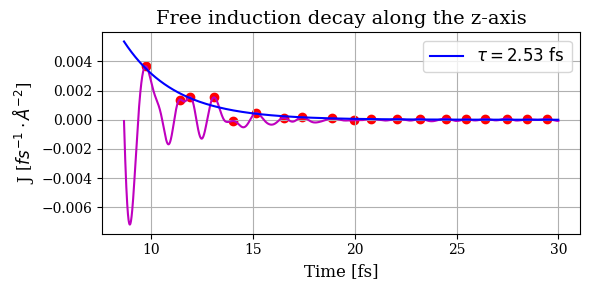

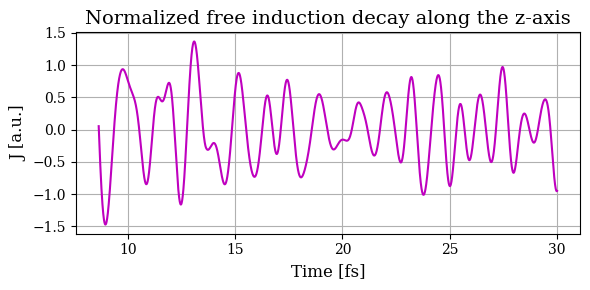

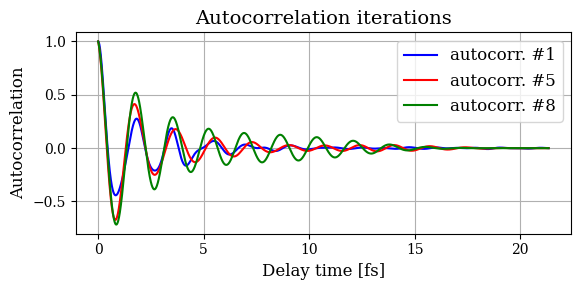

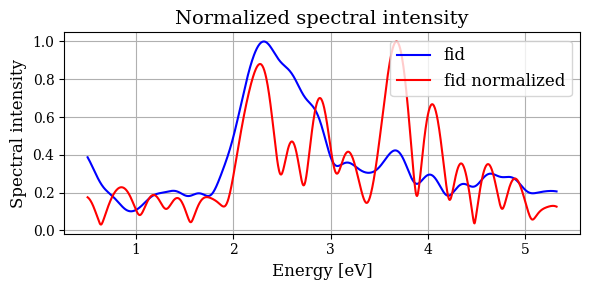

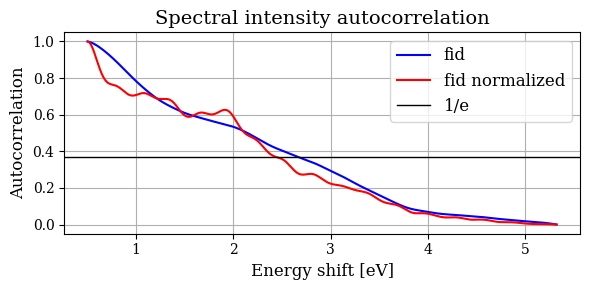

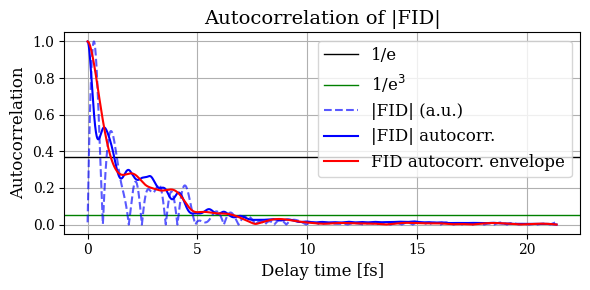

Points check: 
[15.53  16.684 17.952 19.054 20.274 21.424 22.678 23.742 24.468 25.268
 26.258 27.252 28.342 29.424]
[ 2.56300591e-03  1.72827873e-03  7.50562237e-04  4.00218952e-04
  2.52581542e-04  1.35604114e-04  1.74263926e-04 -5.68354379e-06
 -2.91035619e-05 -1.10702980e-04  9.80456634e-05  3.15407796e-05
  6.90486690e-05  9.30347773e-05]
Params:  [7.81020193e-02 2.00000000e+00 0.00000000e+00 1.00000000e+00
 4.02754905e-07]
For c333_amorphous_0.99_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorph_0.976 z-axis fid plots are completed
[ 2.56300591e-03  1.72827873e-03  7.50562237e-04  4.00218952e-04
  2.52581542e-04  1.35604114e-04  1.74263926e-04 -5.68354379e-06
 -2.91035619e-05 -1.10702980e-04  9.80456634e-05  3.15407796e-05
  6.90486690e-05  9.30347773e-05]
4.027549045047322e-07
Mandel's time fot fid normalized signal 3.5032617077374475
For c333_amorphous_0.99_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorph_0.976 z-axis fid data saving in csv format is completed
Mandel's 

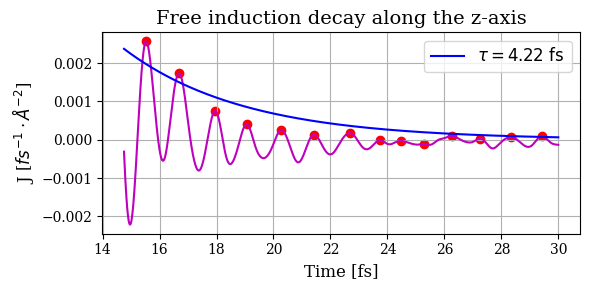

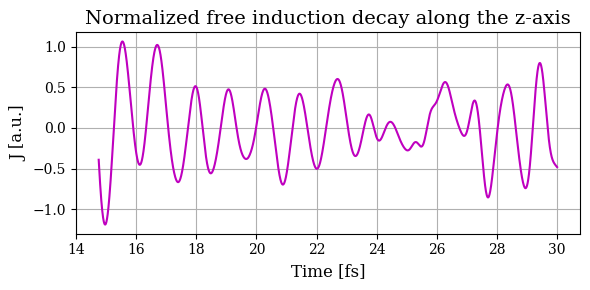

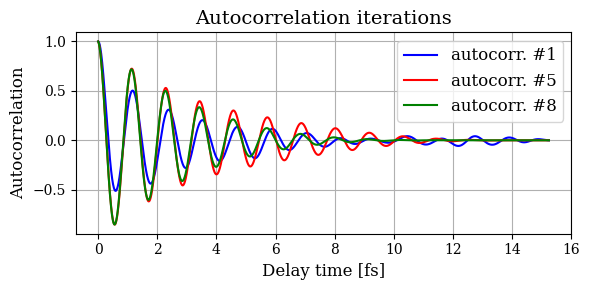

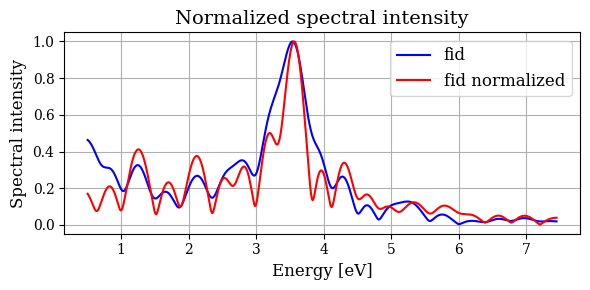

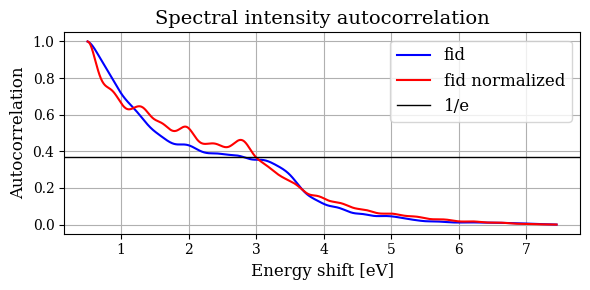

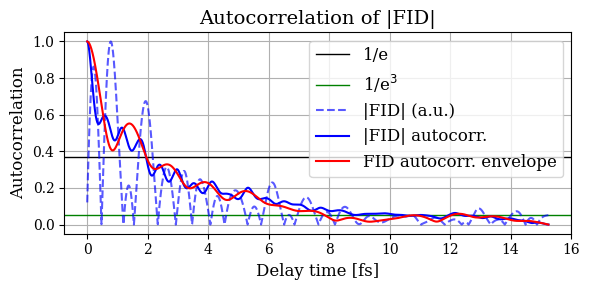

Points check: 
[15.328 16.854 17.746 18.412 18.966 20.274 21.312 22.16  23.51  24.828
 25.596 26.662 27.21  28.222 29.676]
[ 9.56989099e-03  5.35357370e-03  2.24257159e-04  1.14236289e-03
  2.40904990e-04  2.80267003e-03  1.47226181e-03  1.24622746e-03
  1.02834303e-03  3.36846764e-04  3.66209326e-04  6.21761227e-04
 -5.34111642e-07  8.05953166e-04  3.43901842e-04]
Params:  [ 3.21713434e-01  2.00000000e+00  0.00000000e+00  1.00000000e+00
 -1.56937041e-06]
For c333_amorphous_0.95_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 z-axis fid plots are completed
[ 9.56989099e-03  5.35357370e-03  2.24257159e-04  1.14236289e-03
  2.40904990e-04  2.80267003e-03  1.47226181e-03  1.24622746e-03
  1.02834303e-03  3.36846764e-04  3.66209326e-04  6.21761227e-04
 -5.34111642e-07  8.05953166e-04  3.43901842e-04]
-1.5693704052059898e-06
Mandel's time fot fid normalized signal 2.8230370709119135
For c333_amorphous_0.95_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 z-axis fid data saving in csv format is completed
Mande

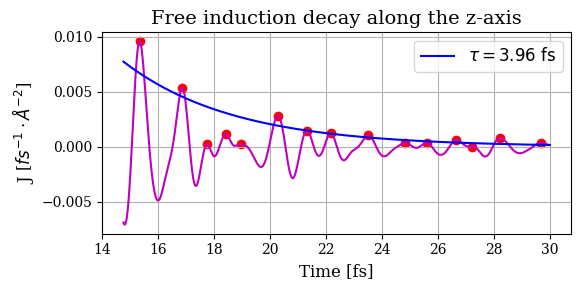

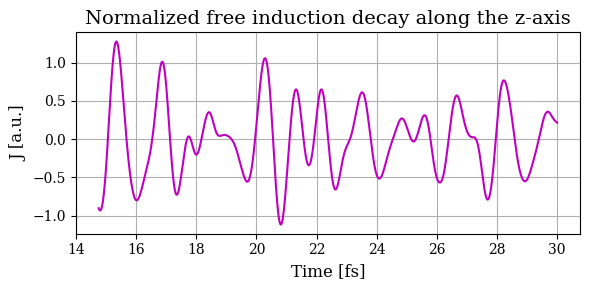

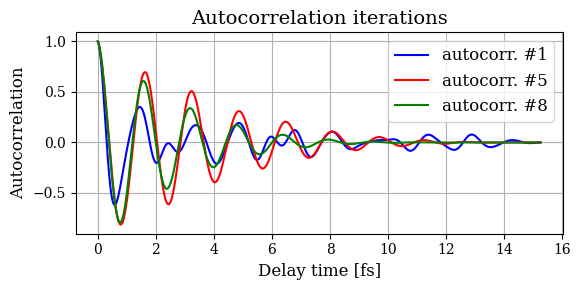

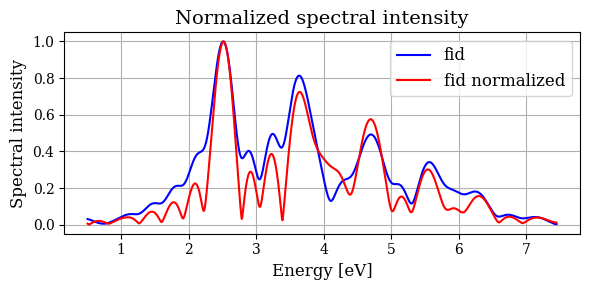

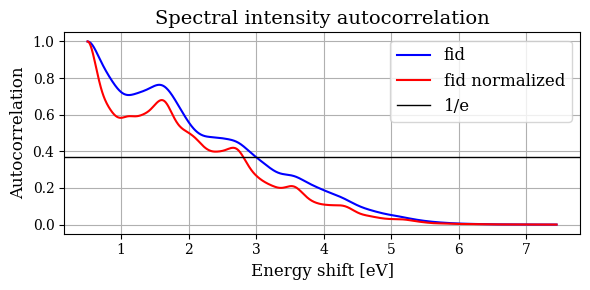

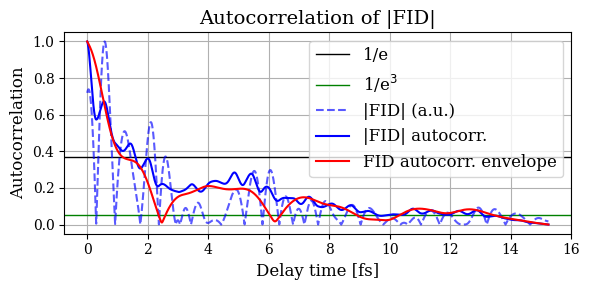

Points check: 
[15.536 16.768 17.834 19.268 20.51  22.142 23.48  24.462 25.65  26.938
 28.502]
[1.54613709e-03 8.32805129e-04 4.32774107e-04 5.91850442e-04
 4.83182698e-04 1.34781681e-04 1.40161873e-04 1.70079256e-04
 2.75689580e-04 1.51875574e-04 8.95476493e-05]
Params:  [ 1.70165872e-02  2.00000000e+00  0.00000000e+00  1.00000000e+00
 -1.58287416e-07]
For c333_amorphous_0.93_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 z-axis fid plots are completed
[1.54613709e-03 8.32805129e-04 4.32774107e-04 5.91850442e-04
 4.83182698e-04 1.34781681e-04 1.40161873e-04 1.70079256e-04
 2.75689580e-04 1.51875574e-04 8.95476493e-05]
-1.5828741560255723e-07
Mandel's time fot fid normalized signal 3.779348729945123
For c333_amorphous_0.93_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 z-axis fid data saving in csv format is completed
Mandel's coherence time: 2.5645957460317743
3.6983924371787156
4.153095856330477
3.940379909351032
3.4646149877379955
2.99425107547018
2.6039422124160883
2.296683517970567
2.0581039256458933

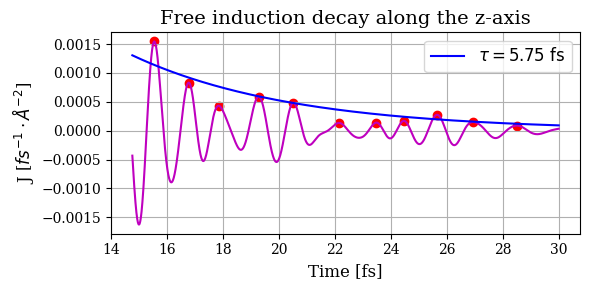

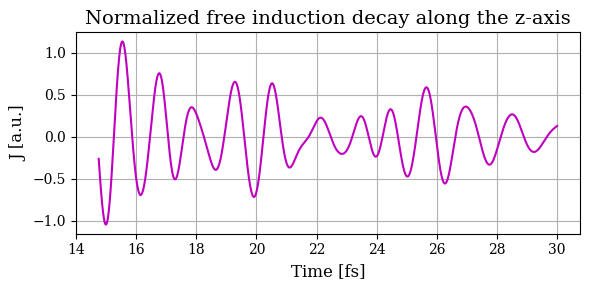

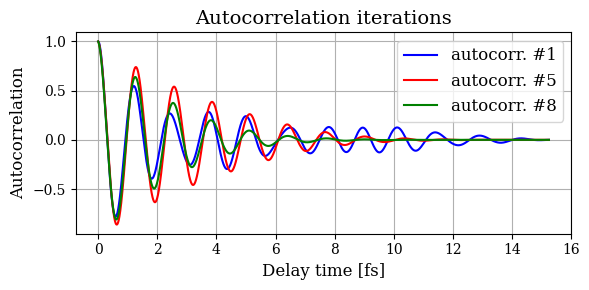

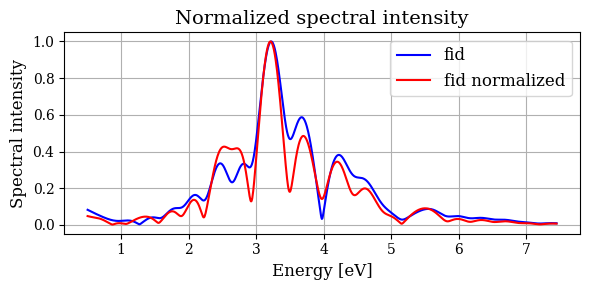

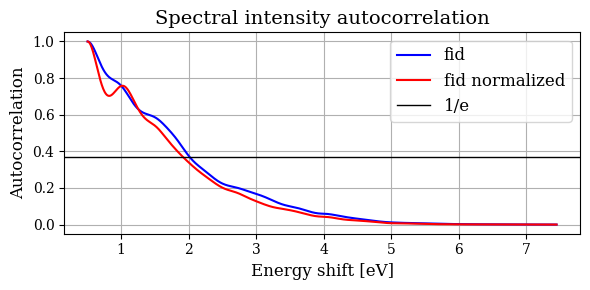

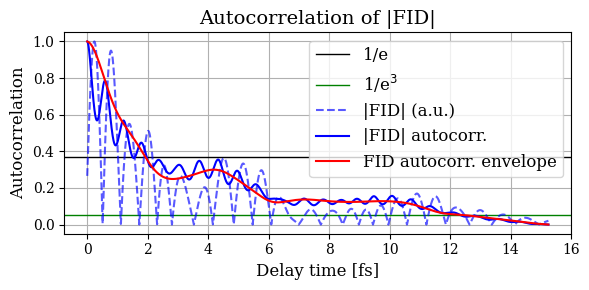

Points check: 
[15.318 16.84  17.744 18.4   18.96  20.25  21.268 22.166 23.498 24.786
 25.564 26.612 27.31  28.18  29.578 29.994]
[ 9.88439489e-03  5.30260587e-03  4.69285909e-04  1.06742915e-03
  2.09053340e-04  2.77169981e-03  1.84326536e-03  1.44917394e-03
  9.01486304e-04  2.07513405e-04  5.82270298e-04  6.43822110e-04
 -1.13751053e-05  4.86322516e-04  2.06428875e-04  6.25855125e-05]
Params:  [7.34909434e-02 2.00000000e+00 0.00000000e+00 1.00000000e+00
 2.18861566e-06]
For c333_amorphous_0.92_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid plots are completed
[ 9.88439489e-03  5.30260587e-03  4.69285909e-04  1.06742915e-03
  2.09053340e-04  2.77169981e-03  1.84326536e-03  1.44917394e-03
  9.01486304e-04  2.07513405e-04  5.82270298e-04  6.43822110e-04
 -1.13751053e-05  4.86322516e-04  2.06428875e-04  6.25855125e-05]
2.188615658189695e-06
Mandel's time fot fid normalized signal 1.9734624844505244
For c333_amorphous_0.92_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid data saving in c

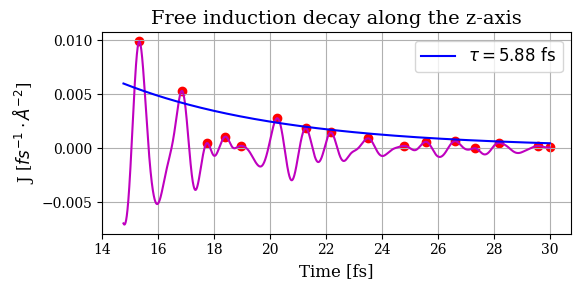

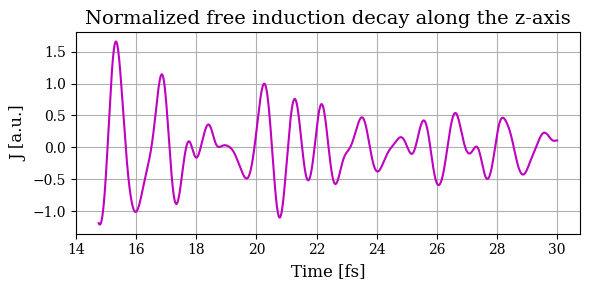

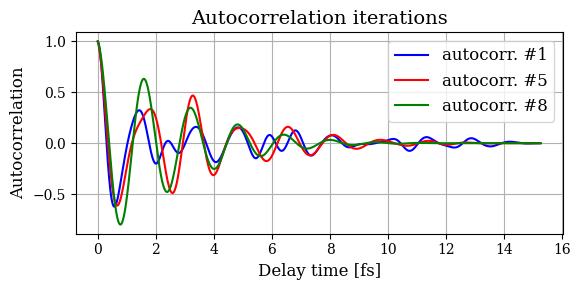

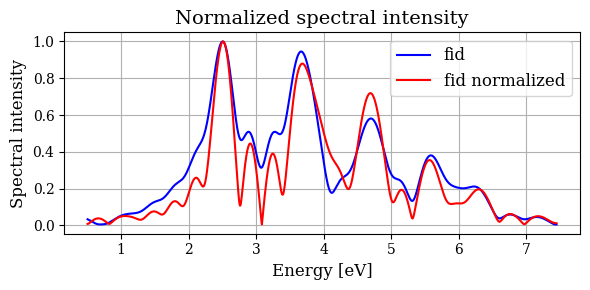

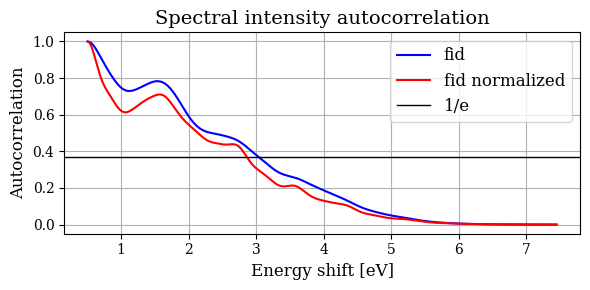

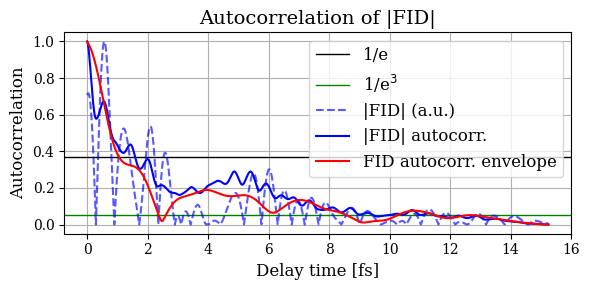

Points check: 
[15.406 16.916 17.794 19.04  20.406 21.384 22.35  23.704 24.866 25.9
 27.376 28.598 29.84 ]
[6.63576934e-03 3.45596012e-03 1.09334436e-04 7.70298748e-04
 1.16855376e-03 4.01327934e-04 6.18210298e-04 3.56974075e-04
 8.55315884e-05 1.92072871e-04 2.27409908e-04 2.67912111e-04
 7.35250028e-05]
Params:  [3.25273897e-01 2.00000000e+00 0.00000000e+00 1.00000000e+00
 1.27358540e-06]
For c333_amorphous_0.90_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid plots are completed
[6.63576934e-03 3.45596012e-03 1.09334436e-04 7.70298748e-04
 1.16855376e-03 4.01327934e-04 6.18210298e-04 3.56974075e-04
 8.55315884e-05 1.92072871e-04 2.27409908e-04 2.67912111e-04
 7.35250028e-05]
1.2735853966801432e-06
Mandel's time fot fid normalized signal 2.865559107599695
For c333_amorphous_0.90_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid data saving in csv format is completed
Mandel's coherence time: 1.5197992518459078
1.6446634117509564
1.9410044781823175
2.2431449743993417
2.6909585235201203
2.

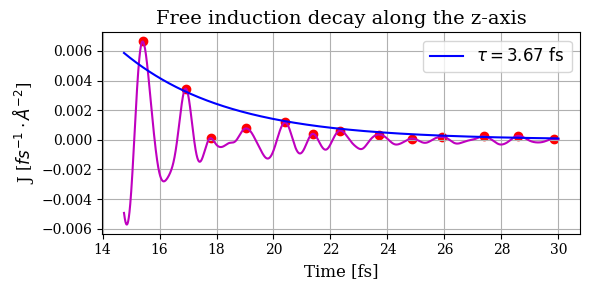

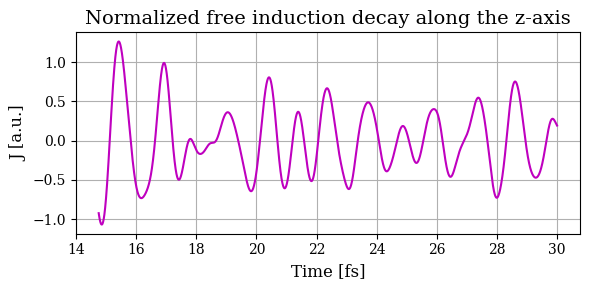

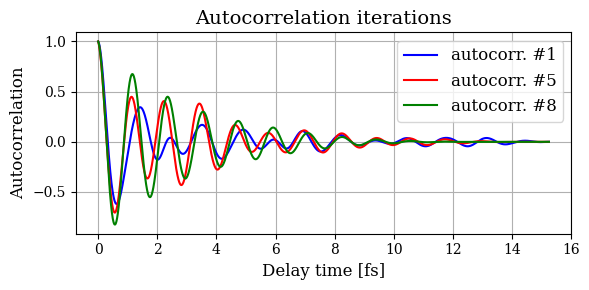

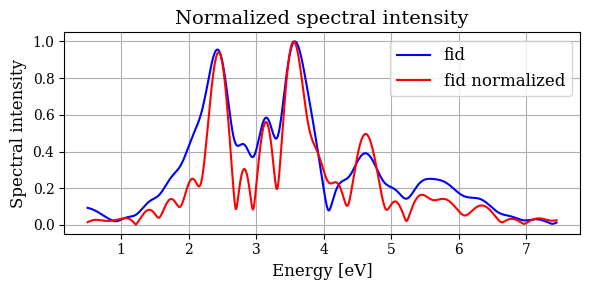

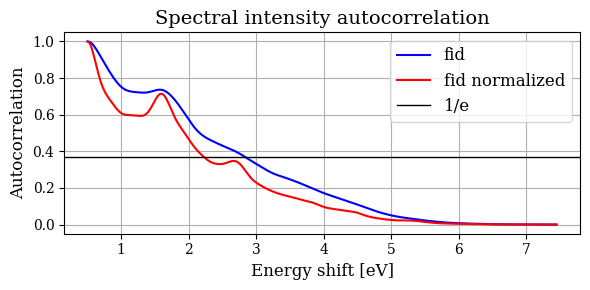

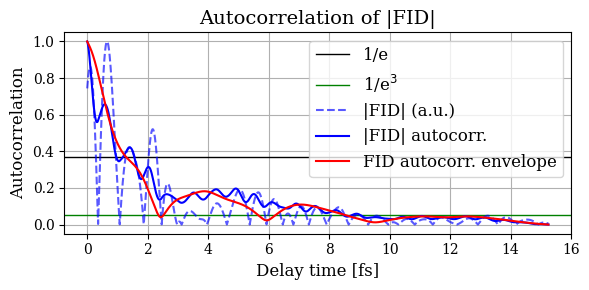

Error is:  0.29633743511999333
 


In [159]:
tau_fid_z_arr = []

auto_corr_mandels_coherence=[]

mandels_coherence_arr=[]
mandels_coherence_abs_v2_arr=[]

autocorr_fid_1_e_arr=[]
autocorr_fid_1_e_abs_v2=[]
autocorr_fid_3_e_arr=[]

normalized_fid_mandels_coherence=[]
normalized_fid_mandels_coherence_abs_v2=[]


eV_autocorrelation_fid=[]
eV_autocorrelation_normalized_fid=[]

eV_autocorrelation_fid_coherence_v2=[]
eV_autocorrelation_fid_normalized_coherence_v2=[]

j=0
for folder in sorted_folders:

    j=j+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2 - m0_cut_4_shift_optimal) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau)

    # ЭЭЭЭЭЭЭЭКСПЕРИМЕНТЫ
    # p0 = [0.02, 0, 20]

    # try:
    #     popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    # except RuntimeError:
    #     print("First fit failed, trying different initial guess...")
    
    #     p0_v2 = [0.05, 0, 6.65]
    #     popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0_v2)

    
    # j0, j_final, tau_pump= popt
    # j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)
    
    # # ratio = j_final/max(delta_Jm_x)
    
    # # # Разностный ток по x
    # # plt.plot(t, Jm_pump_z, color='m')
    # # if tau_pump<30:
    # #     plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
    # # else: plt.plot(t_array_cut, j_fit, '--', color='r')
    # # plt.xlabel('Time [fs]')
    # # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # # plt.title('Matter current density along z, only pump')
    # # plt.legend()
    # # plt.grid(True)
    # # plt.tight_layout()


    # interp_f = interp1d(t_array_cut, j_fit, kind="linear", fill_value="extrapolate")
    # # t_array_cut_full = np.linspace(t_array_cut[0], 30, 15000-m0_cut_4)    # сетка на [t1, t2]
    # j_fit_full = interp_f(t[m0_cut_4:])  
    
    
    # fid_signal = Jm_pump_z[m0_cut_4:]-j_fit_full

    fid_signal = Jm_pump_z[m0_cut_4:]
    
    fid_signal = fid_signal-moving_average_time(fid_signal, 0.002, 10)
        
    
    t_z_exp_fit = t[m0_cut_4:]
    # fid_z = Jm_pump_z[m0_cut_4:]-j_fit_full
    t_peaks_vals, fid_peak_vals = find_halfcycle_maxima(np.array(t_z_exp_fit), np.array(fid_signal))
    
    
    # fit peak points
    t_fit_vals = t_peaks_vals
    y_fit_vals = fid_peak_vals
    
    exclude_array=[]
    # exclude_array = [2, 3, 4]
    t_fit_vals = np.delete(t_fit_vals, exclude_array)
    y_fit_vals = np.delete(y_fit_vals, exclude_array)


    print("Points check: ")
    print(t_fit_vals)
    print(y_fit_vals)
    
    params, cov = fit_exp_gauss(t_fit_vals, y_fit_vals)
    
    A, tau_exp_z, t0, sigma, C = params

    print("Params: ", params)

    tau_fid_z_arr.append(tau_exp_z)
    
    # print("Fit parameters:")
    # print(f"A = {A}")
    # print(f"tau = {tau_exp_z}")
    # print(f"t0 = {t0}")
    # print(f"sigma = {sigma}")
    # print(f"C = {C}")
    
    # построение
    t_fit = t_z_exp_fit
    y_fit = exp_gauss(t_fit, *params)

    xticks_fontsize=10
    yticks_fontsize=10
    legend_fontsize=12
    
    title_fontsize=14
    xlabel_fontsize=12
    ylabel_fontsize=12
    
    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    
    
    plt.plot(t[m0_cut_4:], fid_signal, color='m')
    plt.scatter(t_peaks_vals, fid_peak_vals, color='r')
    plt.plot(t_fit, y_fit, color='b', label= rf"$\tau = {new_taus[j-1]:.2f}\ \mathrm{{fs}}$")
    plt.grid()
    plt.legend(fontsize=legend_fontsize)
    plt.xlabel('Time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]', fontsize=ylabel_fontsize)
    plt.title('Free induction decay along the z-axis', fontsize=title_fontsize)
    plt.tight_layout()

    
    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_fid_z_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " z-axis fid plots are completed")


    print(fid_peak_vals)
    print(C)
    
    normalized_fid_signal=fid_signal/(y_fit+max(fid_peak_vals[-4:])-C**2)
    normalized_fid_signal = normalized_fid_signal-moving_average_time(normalized_fid_signal, 0.002, 5)

    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    # plt.legend(fontsize=legend_fontsize)
    
    plt.plot(t[m0_cut_4:], normalized_fid_signal, color='m')
    plt.grid()
    plt.xlabel('Time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('J [a.u.]', fontsize=ylabel_fontsize)
    plt.title('Normalized free induction decay along the z-axis', fontsize=title_fontsize)
    plt.tight_layout()

    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_normalized_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_normalized_fid_z_' + folder + ".pdf", bbox_inches="tight")
    


    print("Mandel's time fot fid normalized signal", coherence_time(normalized_fid_signal, 0.002))
    normalized_fid_mandels_coherence.append(coherence_time(normalized_fid_signal, 0.002))
    normalized_fid_mandels_coherence_abs_v2.append(coherence_time_v2_abs(normalized_fid_signal, 0.002))

    
    
    each_num=5
    
    fid_data_array=np.array([  t[m0_cut_4:][::each_num], fid_signal[::each_num], y_fit[::each_num]  ])
    
    columns = ["time",  "fid_signal", "fid_exp_fit"]
    df = pd.DataFrame(fid_data_array.T, columns=columns)
    
    
    df.to_csv("all_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", index=False)
    
    with open("all_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", "w") as f:
        f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " z-axis fid data saving in csv format is completed")

    print("Mandel's coherence time:", coherence_time(np.array(fid_signal), 0.002))
    mandels_coherence_arr.append(coherence_time(np.array(fid_signal), 0.002))
    mandels_coherence_abs_v2_arr.append(coherence_time_v2_abs(fid_signal, 0.002))


    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)

    plt.grid()
    plt.xlabel('Delay time [fs]', fontsize=xlabel_fontsize)
    plt.ylabel('Autocorrelation', fontsize=ylabel_fontsize)
    plt.title('Autocorrelation iterations', fontsize=title_fontsize)
    

    
    auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    colors=['b', 'olive', 'r', 'g', 'm', 'orange', 'gold', 'purple', 'slateblue', 'navy', 'darkred']
    
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], auto_corr, label="autocorr. #1", color=colors[0])

    num_auto_corr_iters=10
    auto_corr_coh_vals=[]
    for i in range(num_auto_corr_iters):
    
        new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
        new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
        new_auto_corr = new_auto_corr / new_auto_corr[0]
        
        auto_corr=new_auto_corr

        print(coherence_time(auto_corr, 0.002))
        
        auto_corr_coh_vals.append(coherence_time(auto_corr, 0.002))
    
        if i!=0 and i%(3)==0 and i//3 < 3:
            plt.plot(t[m0_cut_4:]-t[m0_cut_4], new_auto_corr, label= rf"autocorr. #{int(i+2)}", color=colors[int(i//3+1)])

    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)

    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".pdf", bbox_inches="tight")
    
    auto_corr_mandels_coherence.append(max(auto_corr_coh_vals))
    # auto_corr_mandels_coherence.append(coherence_time(auto_corr, 0.002))


    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    
    
    plt.grid()
    plt.title('Normalized spectral intensity', fontsize=title_fontsize)

    plt.xlabel("Energy [eV]", fontsize=xlabel_fontsize)
    plt.ylabel("Spectral intensity", fontsize=ylabel_fontsize)

    
    # second variable is convolve parameter val in eV
    F_ens, F_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)

    i_eV = int(np.where(F_ens > 0.5)[0][0])
    
    plt.plot(F_ens[i_eV:], F_fid[i_eV:], color='b', label='fid')
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)  
    F_ens, F_fid_normalized = fourier_plot_window(normalized_fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)
    plt.plot(F_ens[i_eV:], F_fid_normalized[i_eV:], color='r', label='fid normalized')
    
    plt.legend(fontsize=legend_fontsize)

    plt.tight_layout()


    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".pdf", bbox_inches="tight")



    spectral_intensity_data=np.array([F_ens, F_fid, F_fid_normalized])

    columns = ["energies",  "F_fid", "F_fid_normalized"]
    df = pd.DataFrame(spectral_intensity_data.T, columns=columns)
    
    df.to_csv("all_data/fid/z/data/" + str(j) + "_spectral_intensity_" + folder + ".csv", index=False)
    
    with open("all_data/fid/z/data/" + str(j) + "_spectral_intensity_" + folder + ".csv", "w") as f:
        f.write(r"# Units: Energy [eV], Spectral intensity [normalized] " + "\n")
        df.to_csv(f, index=False)


    
    
    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)


    plt.grid()
    plt.title('Spectral intensity autocorrelation', fontsize=title_fontsize)

    plt.xlabel("Energy shift [eV]", fontsize=xlabel_fontsize)
    plt.ylabel("Autocorrelation", fontsize=ylabel_fontsize)

    auto_corr = np.correlate(F_fid[i_eV:], F_fid[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(F_fid[i_eV:])-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    i_0 = np.where(auto_corr < 0.369)[0][0]
    print("Spectrum autocorrelation time: ")
    print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    plt.plot(F_ens[i_eV:], auto_corr, color='b', label='fid')

    eV_autocorrelation_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    eV_autocorrelation_fid_coherence_v2.append(coherence_time_v2_abs(F_fid[i_eV:], F_ens[1]-F_ens[0]))


    auto_corr = np.correlate(F_fid_normalized[i_eV:], F_fid_normalized[i_eV:], 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(F_fid_normalized[i_eV:])-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    i_0 = np.where(auto_corr < 0.369)[0][0]
    print("Spectrum autocorrelation time: ")
    print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    plt.plot(F_ens[i_eV:], auto_corr, color='r', label='fid normalized')

    eV_autocorrelation_normalized_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    eV_autocorrelation_fid_normalized_coherence_v2.append(coherence_time_v2_abs(F_fid_normalized[i_eV:], F_ens[1]-F_ens[0]))

    
    plt.axhline(y=0.369, color='black', label=rf"1/e", linewidth=1)
    plt.legend(fontsize=legend_fontsize)
    plt.tight_layout()

    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_spectral_intensity_autocorrelation_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_spectral_intensity_autocorrelation_fid_z_' + folder + ".pdf", bbox_inches="tight")
    


    

    plt.figure(figsize=(6, 3))

    plt.xticks(fontsize=xticks_fontsize)
    plt.yticks(fontsize=yticks_fontsize)
    

    plt.grid()
    plt.title('Autocorrelation of |FID|', fontsize=title_fontsize)

    plt.xlabel("Delay time [fs]", fontsize=xlabel_fontsize)
    plt.ylabel("Autocorrelation", fontsize=ylabel_fontsize)
    
    auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    
    plt.axhline(y=0.369, color='black', label = rf"1/e", linewidth=1)
    plt.axhline(y=0.05, color='g', label = rf"1/e$^{3}$", linewidth=1)

    plt.plot(t[m0_cut_4:]-t[m0_cut_4], abs(fid_signal)/max(abs(fid_signal)), color='b', linestyle='--', alpha=0.65, label='|FID| (a.u.)')
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], auto_corr, color='b', label='|FID| autocorr.')
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], get_autocorr_envelope(np.array(fid_signal), 0.002), color='r', label='FID autocorr. envelope')
    

    plt.legend(fontsize=legend_fontsize)

    i_1 = np.where(auto_corr < 0.369)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
    
    i_2 = np.where(auto_corr < 0.05)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])

    autocorr_fid_1_e_arr.append(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])


    
    i_1_v2_abs = np.where(get_autocorr_envelope(np.array(fid_signal), 0.002) < 0.369)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
    autocorr_fid_1_e_abs_v2.append(np.array(t[m0_cut_4:])[int(i_1_v2_abs)]-np.array(t[m0_cut_4:])[0])
    

    
    autocorr_fid_3_e_arr.append(  (np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])/3  )

    plt.tight_layout()


    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_autocorrelation_of_abs_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_autocorrelation_of_abs_fid_z_' + folder + ".pdf", bbox_inches="tight")


    plt.show()
    plt.close()


    
delta_1_tau_arr = 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence) - 1/np.array(mandels_coherence_arr)
print("Error is: ", np.sum(abs(delta_1_tau_arr)))
    

print(" ")

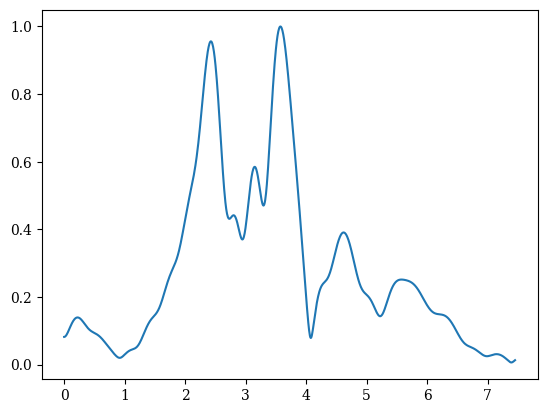

In [161]:
ens, fourier_fid = fourier_plot_window(fid_signal, 0.1, M=40, window="tukey", tukey_alpha=0.3)

plt.plot(ens, fourier_fid)

In [30]:
# print(np.array(eV_autocorrelation_fid)-np.array(eV_autocorrelation_fid_coherence_v2))
# # print(eV_autocorrelation_fid_coherence_v2)

# # print(eV_autocorrelation_normalized_fid)
# print(np.array(eV_autocorrelation_fid_normalized_coherence_v2)-np.array(eV_autocorrelation_normalized_fid))

In [178]:
def l2_normalize(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    a = np.dot(x, y) / np.dot(x, x)
    return a, a*x

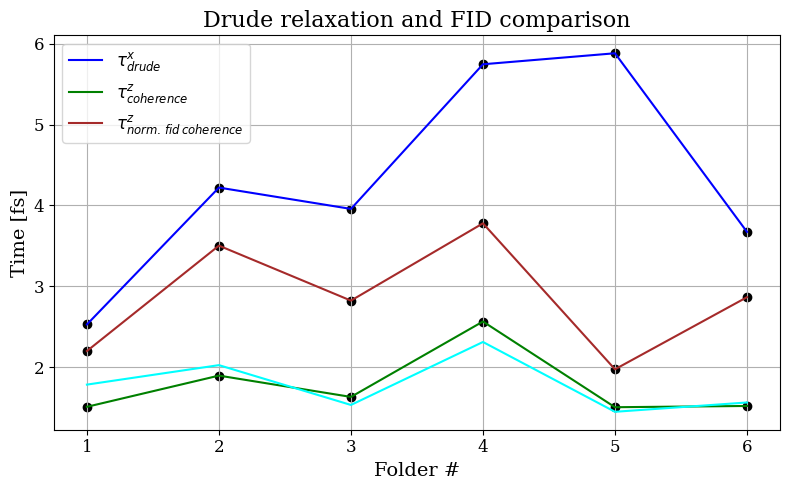

In [181]:
plt.figure(figsize=(8, 5))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

plt.title("Drude relaxation and FID comparison", fontsize=16)
folder_nums = np.linspace(1, len(new_taus), len(new_taus))


plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
plt.scatter(folder_nums, new_taus, color='black')


# plt.plot(folder_nums, tau_fid_z_arr, color='r', label=r'$\tau_{fid}^z$')
# plt.scatter(folder_nums, tau_fid_z_arr, color='black')



plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')

# plt.plot(folder_nums, mandels_coherence_abs_v2_arr, color='g', linestyle='--')




# plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr&coherence}^z$')
# plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')




# plt.plot(folder_nums, np.array(autocorr_fid_1_e_arr), color='orange', label=r'$\tau_{autocorr \, fid \,1 \,e}^z$')
# plt.scatter(folder_nums, np.array(autocorr_fid_1_e_arr), color='black')


# plt.plot(folder_nums, np.array(autocorr_fid_3_e_arr), color='aqua', label=r'$\tau_{autocorr \, fid \,3 \,e}^z$')
# plt.scatter(folder_nums, np.array(autocorr_fid_3_e_arr), color='black')


plt.plot(folder_nums, np.array(normalized_fid_mandels_coherence), color='brown', label=r'$\tau_{norm. \, fid \, coherence}^z$')
plt.scatter(folder_nums, np.array(normalized_fid_mandels_coherence), color='black')

# plt.plot(folder_nums, np.array(normalized_fid_mandels_coherence_abs_v2), color='brown', linestyle='--')



# plt.plot(folder_nums, 1/np.array(eV_autocorrelation_fid), color='yellow', label=r'$\tau_{eV \, fid \, spectrum \, autocorr}^z$')
# plt.scatter(folder_nums, 1/np.array(eV_autocorrelation_fid), color='black')


# spectral width eV -- fs gaussian decay
plt.plot(folder_nums, l2_normalize(1/np.array(eV_autocorrelation_fid_coherence_v2), np.array(mandels_coherence_arr))[1], color='aqua')

# plt.plot(folder_nums, 3/np.array(eV_autocorrelation_fid_normalized_coherence_v2), color='black')


plt.ylabel("Time [fs]", fontsize=14)
plt.xlabel("Folder #", fontsize=14)
plt.xticks(folder_nums)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()

plt.savefig("all_data/fid/" + 'tau_comparison.png', dpi=200)
plt.savefig("all_data/fid/" + 'tau_comparison.pdf', bbox_inches="tight")

plt.show()
plt.close()

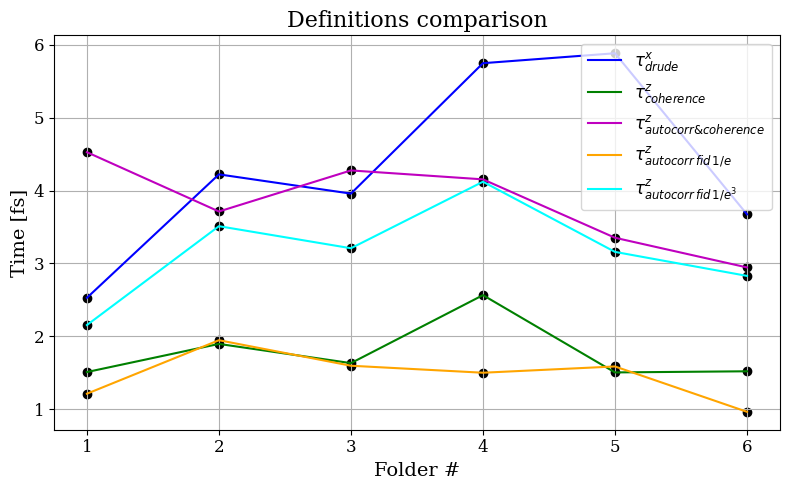

In [163]:
plt.figure(figsize=(8, 5))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.title("Definitions comparison", fontsize=16)
folder_nums = np.linspace(1, len(new_taus), len(new_taus))


plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
plt.scatter(folder_nums, new_taus, color='black')


plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')


plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr&coherence}^z$')
plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')


plt.plot(folder_nums, np.array(autocorr_fid_1_e_arr), color='orange', label=r'$\tau_{autocorr \, fid \,1/e}^z$')
plt.scatter(folder_nums, np.array(autocorr_fid_1_e_arr), color='black')

# plt.plot(folder_nums, np.array(autocorr_fid_1_e_abs_v2), color='orange', linestyle='--')



plt.plot(folder_nums, np.array(autocorr_fid_3_e_arr), color='aqua', label=r'$\tau_{autocorr \, fid \,1/e^{3}}^z$')
plt.scatter(folder_nums, np.array(autocorr_fid_3_e_arr), color='black')


plt.ylabel("Time [fs]", fontsize=14)
plt.xlabel("Folder #", fontsize=14)
plt.xticks(folder_nums)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()

plt.savefig("all_data/fid/" + 'tau_comparison_v2.png', dpi=200)
plt.savefig("all_data/fid/" + 'tau_comparison_v2.pdf', bbox_inches="tight")

plt.show()
plt.close()

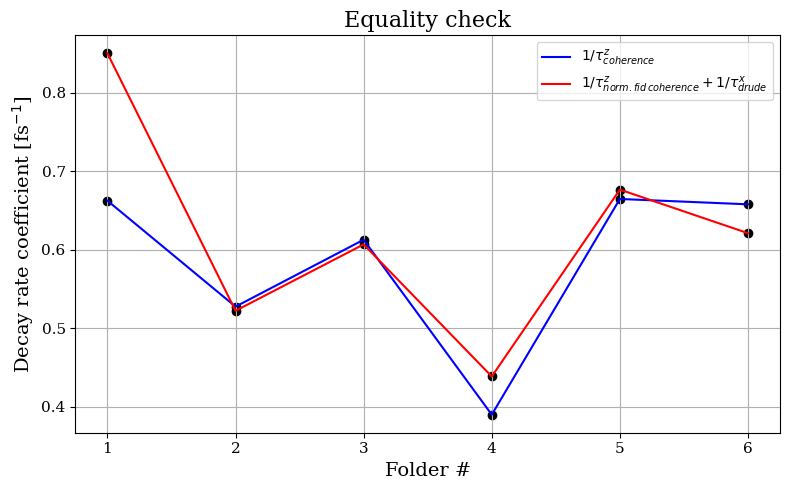

In [164]:
plt.figure(figsize=(8, 5))


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.title("Equality check", fontsize=16)

plt.ylabel(r"Decay rate coefficient [fs$^{-1}$]", fontsize=14)
plt.xlabel("Folder #", fontsize=14)

folder_nums = np.linspace(1, len(new_taus), len(new_taus))
plt.xticks(folder_nums)

plt.plot(folder_nums, 1/np.array(mandels_coherence_arr), color='b', label=r'$1/\tau_{coherence}^z$')
plt.scatter(folder_nums, 1/np.array(mandels_coherence_arr), color='black')

# plt.plot(folder_nums, 1/np.array(mandels_coherence_abs_v2_arr), color='b', linestyle='--')


# plt.plot(folder_nums, np.array(normalized_fid_mandels_coherence_abs_v2), color='brown', linestyle='--')
# plt.plot(folder_nums, mandels_coherence_abs_v2_arr, color='g', linestyle='--')


plt.plot(folder_nums, 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence), color='r', label=r'$1/\tau_{norm.fid \, coherence}^z + 1/\tau_{drude}^x$')
plt.scatter(folder_nums, 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence), color='black')

# plt.plot(folder_nums, 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence_abs_v2), color='r', linestyle='--')


# plt.plot(folder_nums, 1/np.array(tau_fid_z_arr) + 1/np.array(normalized_fid_mandels_coherence), color='orange', label=r'$1/\tau_{norm.fid \, coherence}^z + 1/\tau_{fid}^z$')
# plt.scatter(folder_nums, 1/np.array(tau_fid_z_arr) + 1/np.array(normalized_fid_mandels_coherence), color='black')

# plt.plot(folder_nums, 1/np.array(tau_fid_z_arr) + 1/np.array(normalized_fid_mandels_coherence_abs_v2), color='orange', linestyle='--')


plt.legend(fontsize=11)
plt.grid()
plt.tight_layout()

plt.savefig("all_data/fid/" + 'decay_rate_equality_check.png', dpi=200)
plt.savefig("all_data/fid/" + 'decay_rate_equality_check.pdf', bbox_inches="tight")


plt.legend(fontsize=10)


plt.show()
plt.close()

## fid draft

In [76]:
# # По определению Влада

# # plt.plot(t[m0_cut_4:], fid_signal/max(fid_signal))

# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct")
# ACF = ACF/max(ACF)
# N = len(fid_signal)
# i1 = N - 1
# plt.plot(t[m0_cut_4:], abs(ACF[i1:]))

# ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
# ACF_envelope /= np.max(ACF_envelope)
# plt.plot(t[m0_cut_4:], ACF_envelope[i1:])


# print(2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=0.002))

# # А тут огибающую сделаем сами взяв автокорреляцию от модуля сигнала и взяв интеграл по Манделю!

# auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# plt.plot(t[m0_cut_4:], auto_corr)

# print(2.0 * scipy.integrate.simpson(auto_corr**2, dx=0.002))

In [75]:
# # Теперь сделаем просто автокорреляцию от модуля сразу

# # plt.plot(t[m0_cut_4:], fid_signal/max(fid_signal))

# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct")
# ACF = ACF/max(ACF)
# N = len(fid_signal)
# i1 = N - 1
# plt.plot(t[m0_cut_4:], ACF[i1:])

# ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
# ACF_envelope /= np.max(ACF_envelope)
# plt.plot(t[m0_cut_4:], ACF_envelope[i1:])


# print(2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=0.002))

In [74]:
# auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# plt.plot(t[m0_cut_4:], auto_corr)

In [73]:
# plt.plot(t[m0_cut_4:], fid_signal)

# print("Vlad's coherence time of fid_signal: ", coherence_time(fid_signal, 0.002))
# print("Vlad's coherence time of abs(fid_signal): ", coherence_time(abs(fid_signal), 0.002))

In [72]:
# tau0 = 1  # fs
# dt = 0.001
# t = np.arange(0, 15, dt)
# y = np.exp(-t/tau0)

# plt.plot(t, y)

# print("theory: 2*sigma =", 2*sigma, "fs")
# print("wtf", coherence_time_v2_abs(y, dt))

In [71]:
# sigma = 1  # fs
# dt = 0.001
# t = np.arange(-10, 15, dt)


# y = np.exp(-((t-5)**2) / (2*sigma**2))
# plt.plot(t, y)

# print("theory: 2*sigma =", 2*sigma, "fs")
# print("coherence_v2", coherence_time_v2_abs(y, dt))
# print("coherence_v1", coherence_time(y, dt))

In [70]:
# sigma = 1  # fs
# dt = 0.001
# t = np.arange(-10, 15, dt)

# for alpha in range(3):
#     y = np.sin(4*t)*np.exp(-((t-5)**2) / (2*sigma**2)) + np.sin((alpha+5)*t)*np.exp(-((t-4.5)**2) / (2*sigma**2))
    
#     plt.plot(t, y)
    
#     print("theory: 2*sigma =", 2*sigma, "fs")
#     print("coherence_v2", coherence_time_v2_abs(y, dt))
#     print("coherence_v1", coherence_time(y, dt))

In [69]:
# auto_corr = np.correlate(y, y, 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(y)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# plt.plot(t, auto_corr)
# # plt.plot(t, y)

# i_1_e = np.where(auto_corr < 0.369)[0][0]

# print(t[i_1_e]-t[0])

In [68]:
# ens_eV, Fw_y = fourier_plot(y, dt)

# plt.plot(ens_eV, Fw_y)

In [67]:
# ens_eV, Fw_y = fourier_plot(y, 0.0001)

# # plt.plot(ens_eV, Fw_y)

In [66]:
# N = len(fid_signal)

# # убираем среднее (рекомендовано)
# x = np.array(fid_signal)-np.mean(fid_signal)

# # FFT
# M=4
# xpad = np.pad(x, (0, (M-1)*len(x)))
# X = np.fft.rfft(xpad)
# freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs

# # ---- единственная физическая константа ----
# h_eV_fs = 4.135667696                # eV·fs
# E_eV = h_eV_fs * freq

# # амплитуда
# A = np.abs(X)

# # график
# # plt.plot(E_eV, A, color='b')

# plt.plot(E_eV, gaussian_convolve(A, 1.2), color='b')

# plt.xlabel("Energy (eV)")
# plt.ylabel("|FFT|")
# plt.ylim(0, max(A)*1.1)
# plt.xlim(0, E_eV[-1]/120)
# plt.grid()
# plt.show()

# print(coherence_time(A[:int(110*M/4)], E_eV[1]-E_eV[0]), "eV width")
# print(E_eV[1]-E_eV[0])
# print(E_eV[:int(110*M/4)][-1], "max eV")

# plt.plot(E_eV[:int(110*M/4)], A[:int(110*M/4)])

In [420]:
# E_eV[:int(110*M/4)]

In [65]:
# N = len(fid_signal)

# # убираем среднее (рекомендовано)
# x = np.array(fid_signal)-np.mean(fid_signal)

# # FFT
# M=10
# xpad = np.pad(x, (0, (M-1)*len(x)))
# X = np.fft.rfft(xpad)
# freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs

# # ---- единственная физическая константа ----
# h_eV_fs = 4.135667696                # eV·fs
# E_eV = h_eV_fs * freq

# # амплитуда
# A = np.abs(X)

# # график
# plt.plot(E_eV, A, color='b')
# plt.xlabel("Energy (eV)")
# plt.ylabel("|FFT|")
# plt.ylim(0, max(A)*1.1)
# # plt.xlim(0, E_eV[-1]/120)
# plt.grid()
# plt.show()

# print(coherence_time(A[:int(110*M/4)], E_eV[1]-E_eV[0]), "eV width")
# print()
# print(E_eV[:int(110*M/4)][-1], "max eV")

In [64]:
# F_signal = A[:int(110*M/4)]
# F_signal = A

# auto_corr = np.correlate(F_signal, F_signal, 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(F_signal)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# i_0 = np.where(auto_corr < 0.369)[0][0]
# print(np.array(E_eV[:int(110*M/4)])[int(i_0)]-np.array(E_eV[:int(110*M/4)])[0])

In [63]:
# plt.plot(E_eV[:int(110*M/4)], auto_corr)

In [62]:
# auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# plt.plot(t[m0_cut_4:], auto_corr)

# i_1 = np.where(auto_corr < 0.369)[0][0]
# print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])

# i_2 = np.where(auto_corr < 0.136)[0][0]
# print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])

In [61]:
# # plt.plot(t[m0_cut_4:], abs(fid_signal))
# plt.plot(t[m0_cut_4:], auto_corr)

In [60]:
# plt.plot(t[m0_cut_4:], fid_signal)
# plt.plot(t[m0_cut_4:], fid_signal**2)

In [175]:
# auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]  

# plt.plot(t[m0_cut_4:], auto_corr)

# for i in range(20):

#     new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
#     new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
#     new_auto_corr = new_auto_corr / new_auto_corr[0]
    
#     auto_corr=new_auto_corr

#     print(coherence_time(auto_corr, 0.002))

#     if i%5==0:
#         plt.plot(t[m0_cut_4:], new_auto_corr)



In [176]:
         
# auto_corr = np.correlate(signal, signal, 'full')   # линейная корреляция (вне отрезка = 0)
# auto_corr = auto_corr[len(x)-1:]                 # лаги >= 0
# auto_corr = auto_corr / auto_corr[0]                     # нормировка: R(0)=1

# dt = t[1] - t[0]
# tau = np.arange(len(auto_corr)) * dt

# plt.plot(tau, auto_corr)
# plt.xlabel(r'$\tau$')
# plt.ylabel(r'$R(\tau)$')
# plt.show()

## drude old

In [55]:
# def effecive_mass_model(alpha, a, b, c):
#     return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [56]:
# delta_start_drude_fit = 300

# def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     t = data_both['time_fs']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     step_dt = 0.002
    


#     t_probe, t_pump = get_pulse_durations(folder)

#     m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
#     m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
#     m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
#     m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    
    
#     dt = np.diff(t, prepend=t[0])
    
    
#     alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
#     fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
#     alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
#     # --- Задаём поле в дискретных точках ---
#     t_array = np.array(t[m0_cut_2:])         # сетка времени
#     E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
#     # --- Решение через явный шаг Эйлера ---
    
#     j_euler = np.zeros_like(t_array)
#     j_euler[0] = j0
    
#     for k in range(len(t_array)-1):
#         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
#     return j_euler[::1]

In [97]:
# new_taus = []
# new_j_finals = []
# arr_abc = []

# alphas_start = []
# alphas_final = []

    
# folder = sorted_folders[0]

# j=0
# num_folder=0
# for folder in sorted_folders:

#     j=j+1
#     num_folder=num_folder+1
    
#     t_probe, t_pump = get_pulse_durations(folder)
    
#     m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
#     m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
#     m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
#     m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']


#     dt = np.diff(t, prepend=t[0])
    
#     arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
#     a_start = arr[m0_cut_2-m0_cut_3]
#     a_fin = arr[-1]

#     alphas_start.append(a_start)
#     alphas_final.append(a_fin)
    
    
#     # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)
    
    
#     fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
#     delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x
    
#     # t_array_cut = np.array(t[m0_cut_2:])[::50]
#     # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
#     # # (dummy_t, j0, fit_alpha, j_final)
#     # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
#     # # print(len(t_array_cut), len(j_exp))
#     # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
#     # j0, fit_alpha = popt
#     # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)
    
#     plt.figure(figsize=(7,5))
#     # plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
#     plt.title("Generalized Drude model fit", fontsize=15, y=1.03)
#     plt.plot(t, delta_Jm_x, color='b')
#     # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
#     plt.xlabel("Time [fs]", fontsize=12)
#     plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)

#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)

#     plt.legend(fontsize=12)
    
    
#     t_array_cut = np.array(t[m0_cut_2:])[::1]
#     j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
#     # (dummy_t, j0, fit_alpha, j_final)
#     p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
#     # print(len(t_array_cut), len(j_exp))
#     popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
#     [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
#     ))
#     j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
#     j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)
    
#     new_taus.append(fit_tau_val)
#     new_j_finals.append(fit_j_fin_val)
    
#     plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
#     plt.legend()
#     plt.grid()
#     arr_abc.append((a, b, c))
#     print(a, b, c)

#     plt.tight_layout()

#     plt.savefig("all_data/drude/ims/png/" + str(j)+ '_drude_fit_' + folder + ".png", dpi=200)
#     plt.savefig("all_data/drude/ims/pdf/" + str(j)+ '_drude_fit_' + folder + ".pdf", bbox_inches="tight")

#     print("For " + folder + " drude fit plots are completed")




#     j_fit_extended = np.concatenate(([None]*m0_cut_2, j_fit))
    
#     drude_current_arr=np.array([t, delta_Jm_x, j_fit_extended])

#     columns = ["time",  "delta_Jm_x", "delta_Jm_x_drude_fit"]
#     df = pd.DataFrame(drude_current_arr.T, columns=columns)
    
    
#     df.to_csv("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", index=False)
    
#     with open("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", "w") as f:
#         f.write(r"# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
#         df.to_csv(f, index=False)
    
#     print("For " + folder + " drude fit current data saving in csv format is completed")

    


# print(" ")

In [98]:
# from matplotlib.colors import to_hex

# def blue_red_gradient(n):
#     """
#     Возвращает список из n цветов (hex),
#     создающих линейный градиент от синего к красному.
#     """
#     colors = []
    
#     for i in range(n):
#         t = i / (n - 1)  # параметр от 0 до 1
        
#         r = t            # красный растёт
#         g = 0            # зелёный фиксирован
#         b = 1 - t        # синий убывает
        
#         colors.append(to_hex((r, g, b)))
    
#     return colors

In [98]:
# colors=['coral', 'b', 'r', 'm', 'g', 'orange', 'gold', 'purple', 'slateblue', 'olive', 'navy', 'darkred']

# if len(sorted_folders)<12:


#     plt.figure(figsize=(8,5))
#     plt.title("Drude mass dependence on wave vector", fontsize=15)
    
    
#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)
    
#     plt.legend(fontsize=12)
    
#     plot_part=1
#     num_folder=0
#     for (a0, b0, c0) in arr_abc:
#         num_folder+=1
#         if num_folder!=0:
#             plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), 
#             [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
#             plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2, color=colors[num_folder-1])

#     j=j+1
#     plt.grid()
#     plt.legend()
#     plt.xlabel(r'$\Delta \, k \, [\pi/a]$', fontsize=12)
#     # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
#     # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
#     plt.ylabel(r'$m^{*}\, [m_e]$', fontsize=12, rotation=0,  labelpad=30)
#     plt.tight_layout()
    
#     plt.savefig("all_data/drude/ims/png/" + 'drude_m_dependence.png', dpi=200)
#     plt.savefig("all_data/drude/ims/pdf/" + 'drude_m_dependence.pdf', bbox_inches="tight")

#     print("Effective mass plots are completed")
#     print(" ")


    
#     # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

In [99]:
# num_folder=0
# for (a0, b0, c0) in arr_abc:
#     num_folder+=1

#     delta_k_vals = np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)
    
#     effective_mass_vals = [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
#     plot_part*alphas_final[num_folder-1], 500)]
    
#     effective_mass_data=np.array([delta_k_vals, effective_mass_vals])

#     columns = ["delta_k",  "effective_mass"]
#     df = pd.DataFrame(effective_mass_data.T, columns=columns)
    
    
#     df.to_csv("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", index=False)
    
#     with open("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", "w") as f:
#         f.write(r"# Units: Wave vector during the probe pulse $\Delta k$ [$\pi/a$], Effective mass $m^{*}$ [$m_e$]" + "\n")
#         df.to_csv(f, index=False)
    
#     print("For " + sorted_folders[num_folder-1] + " effective mass data saving in csv format is completed")


# print(" ")

In [57]:
# plt.figure(figsize=(6, 4))

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.legend(fontsize=12)

# plt.title("Drude relaxation and FID comparison", fontsize=14)
# folder_nums = np.linspace(1, len(new_taus), len(new_taus))
# plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
# plt.plot(folder_nums, tau_fid_z_arr, color='r', label=r'$\tau_{fid}^z$')

# plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
# plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')


# plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr_coherence}^z$')
# plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')

# plt.scatter(folder_nums, new_taus, color='black')
# plt.scatter(folder_nums, tau_fid_z_arr, color='black')
# plt.ylabel("Time [fs]", fontsize=12)
# plt.xlabel("Folder #", fontsize=12)
# plt.xticks(folder_nums)
# plt.legend(fontsize=12)
# plt.grid()
# plt.tight_layout()

# plt.savefig("all_data/fid/" + 'tau_comparison.png', dpi=200)
# plt.savefig("all_data/fid/" + 'tau_comparison.pdf', bbox_inches="tight")

## draft

In [18]:
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# pulse_data_both = pd.read_csv(
#     folder + '/both_pulses_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_pump = pd.read_csv(
#     folder + '/pump_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_probe = pd.read_csv(
#     folder + '/probe_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# pulse_data_both.columns = [
#     'Energy_eV',

#     'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
#     'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
#     'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',

#     'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
#     'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
#     'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',

#     'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
#     'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
#     'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
# ]

# pulse_data_pump.columns  = pulse_data_both.columns

# pulse_data_probe.columns = pulse_data_both.columns


# energies = pulse_data_both['Energy_eV']


# Abs2_Jm_both_z  =  pulse_data_both['Abs2_Jm_z']
# Abs2_Jm_pump_z  =  pulse_data_pump['Abs2_Jm_z']
# Abs2_Jm_probe_z =  pulse_data_probe['Abs2_Jm_z']

# Abs2_Jm_both_x  =  pulse_data_both['Abs2_Jm_x']
# Abs2_Jm_pump_x  =  pulse_data_pump['Abs2_Jm_x']
# Abs2_Jm_probe_x =  pulse_data_probe['Abs2_Jm_x']

# Abs2_Jm_both_y  =  pulse_data_both['Abs2_Jm_y']
# Abs2_Jm_pump_y  =  pulse_data_pump['Abs2_Jm_y']
# Abs2_Jm_probe_y =  pulse_data_probe['Abs2_Jm_y']

In [349]:
# plt.plot(energies, Abs2_Jm_both_x, color='b')
# plt.plot(energies, Abs2_Jm_pump_x, color='r')
# plt.plot(energies, Abs2_Jm_probe_x, color='g')
# plt.xlim(0, 6)
# plt.ylim(0, 0.0001)

## draft

In [350]:
# def effecive_mass_model(alpha, a, b, c):
#     return 1/(a**2 * alpha**4 + 0*alpha + c)

In [351]:
# def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     t = data_both['time_fs']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     step_dt = 0.002
    
#     m0_cut_2 = 6250
    
#     dt = np.diff(t, prepend=t[0])
    
    
#     alpha_E_t = np.cumsum(-2.64*El_f_probe_x[5250:]*dt[5250:])
#     fit_alpha_E_t = alpha_E_t[1000:]
    
#     alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
#     # --- Задаём поле в дискретных точках ---
#     t_array = np.array(t[m0_cut_2:])         # сетка времени
#     E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
#     # --- Решение через явный шаг Эйлера ---
    
#     j_euler = np.zeros_like(t_array)
#     j_euler[0] = j0
    
#     for k in range(len(t_array)-1):
#         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
#     return j_euler[::1]

In [58]:
# get_n_excited_electrons(sorted_folders[0])[0]

In [59]:
# sorted_folders

In [352]:
# plt.figure(figsize=(8,5))
# plt.title("Drude factor dependence on disorder")

# plot_part=1
# num_folder=0
# for (a0, b0, c0) in arr_abc:
#     num_folder+=1
#     if num_folder!=0:
#         plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2)

# plt.grid()
# plt.legend()
# plt.xlabel(r'$\Delta \, k \, [\pi/a]$')
# # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
# # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
# plt.ylabel(r'$m^{*}\, [m_e]$', rotation=0,  labelpad=30)
# plt.show()

# # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

## draft FID

In [353]:
# new_taus = []
# new_j_finals = []
# arr_abc = []

    
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)


# fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)



# delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x

# # t_array_cut = np.array(t[m0_cut_2:])[::50]
# # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
# # # (dummy_t, j0, fit_alpha, j_final)
# # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
# # # print(len(t_array_cut), len(j_exp))
# # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
# # j0, fit_alpha = popt
# # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)

# plt.figure(figsize=(8,5))
# plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
# plt.plot(t, delta_Jm_x, color='b')
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
# plt.xlabel("Time [fs]")
# plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]")


# t_array_cut = np.array(t[m0_cut_2:])[::1]
# j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
# # (dummy_t, j0, fit_alpha, j_final)
# p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
# # print(len(t_array_cut), len(j_exp))
# popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
# [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
# ))
# j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
# j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)

# new_taus.append(fit_tau_val)
# new_j_finals.append(fit_j_fin_val)

# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.legend()
# plt.grid()
# arr_abc.append((a, b, c))
# print(a, b, c)

In [354]:
# import numpy as np
# import pandas as pd
# from scipy.interpolate import CubicSpline

# def build_nonFID_component_with_zero_plateau(
#     t,                 # pd.Series или np.ndarray, полная сетка времени
#     t_array_cut,       # np.ndarray, время для друде-фита (начиная ~12.5 fs)
#     j_fit,             # np.ndarray, значения друде-фита
#     t_zero_end=9.0,    # fs: до этого времени nonFID принудительно 0
#     halfmax=0.5,       # t1 = первая точка, где j_fit >= halfmax*max
# ):
#     t_full = np.asarray(t, dtype=float)
#     t_cut = np.asarray(t_array_cut, dtype=float)
#     j_cut = np.asarray(j_fit, dtype=float)

#     if t_cut.shape != j_cut.shape:
#         raise ValueError("t_array_cut и j_fit должны быть одинаковой длины.")

#     # сортировка на всякий случай
#     order = np.argsort(t_cut)
#     t_cut = t_cut[order]
#     j_cut = j_cut[order]

#     # --- t1 по halfmax ---
#     jmax = np.nanmax(j_cut)
#     if not np.isfinite(jmax) or jmax == 0:
#         raise ValueError("j_fit выглядит нулевым/некорректным (max=0 или NaN).")

#     thresh = halfmax * jmax
#     idxs = np.flatnonzero(j_cut >= thresh)
#     if len(idxs) == 0:
#         raise ValueError("Не нашёл точку, где j_fit >= halfmax * max(j_fit).")
#     i1 = idxs[0]
#     if i1 >= len(j_cut) - 1:
#         raise ValueError("Точка halfmax слишком близко к концу — нельзя оценить производную.")

#     t1 = t_cut[i1]
#     y1 = j_cut[i1]
#     dydt1 = (j_cut[i1 + 1] - j_cut[i1]) / (t_cut[i1 + 1] - t_cut[i1])

#     # проверка, что зона нулевого плато действительно раньше стыка
#     if t1 <= t_zero_end:
#         raise ValueError(
#             f"Получилось t1={t1:.3g} fs <= t_zero_end={t_zero_end:.3g} fs. "
#             "Нужно уменьшить t_zero_end или иначе выбирать t1."
#         )

#     # --- полиномное включение, но начиная с t_zero_end ---
#     # Используем τ = t - t0z, где t0z = t_zero_end
#     # y(τ) = a τ^3 + b τ^2
#     # y(0)=0 и y'(0)=0 автоматически
#     # Подбираем a,b так, чтобы в τ1 = (t1 - t0z): y=y1 и dy/dt = dydt1
#     tau1 = t1 - t_zero_end
#     a = (dydt1 * tau1 - 2.0 * y1) / (tau1**3)
#     b = (3.0 * y1 - dydt1 * tau1) / (tau1**2)

#     nonFID = np.zeros_like(t_full)

#     # t <= t_zero_end : строго 0
#     # t_zero_end < t < t1 : полином по τ
#     s_poly = (t_full > t_zero_end) & (t_full < t1)
#     tau = t_full[s_poly] - t_zero_end
#     nonFID[s_poly] = a * tau**3 + b * tau**2

#     # t >= t1 : сплайн по Drude fit (с экстраполяцией)
#     spline = CubicSpline(t_cut, j_cut, extrapolate=True)
#     s_spline = t_full >= t1
#     nonFID[s_spline] = spline(t_full[s_spline])

#     info = {
#         "t_zero_end": t_zero_end,
#         "t1": t1,
#         "y1": y1,
#         "dydt1": dydt1,
#         "a": a,
#         "b": b,
#         "halfmax": halfmax,
#     }
#     return nonFID, info


# def subtract_nonFID_and_get_FID_with_zero_plateau(
#     t, delta_Jm_x, t_array_cut, j_fit, t_zero_end=9.0, halfmax=0.5
# ):
#     nonFID, info = build_nonFID_component_with_zero_plateau(
#         t=t,
#         t_array_cut=t_array_cut,
#         j_fit=j_fit,
#         t_zero_end=t_zero_end,
#         halfmax=halfmax,
#     )

#     if isinstance(delta_Jm_x, pd.Series):
#         fid_vals = delta_Jm_x.values - nonFID
#         fid = pd.Series(fid_vals, index=delta_Jm_x.index, name="FID_component")
#         nonFID_out = pd.Series(nonFID, index=delta_Jm_x.index, name="nonFID_component")
#     else:
#         fid = np.asarray(delta_Jm_x, dtype=float) - nonFID
#         nonFID_out = nonFID

#     return fid, nonFID_out, info


In [355]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [356]:
# import scipy

# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# print("Mandel's coherence time: ",coherence_time(fid, 0.002))
# print("Drude relaxation time: ", fit_tau_val)

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID", color='b')
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# # plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [357]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=10.5,   # твоя физическая “ноль-зона”
#     halfmax=0.5
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# plt.axvline(info["t1"], linestyle="--", label="t1")
# plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [358]:
# def coherence_time(Y, dt) -> float:
#     r"""
#     Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

#     The function implements Mandel's coherence time. It calculates the autocorrelation
#     function of the given signal, then it calculates the complex envelope of the
#     autocorrelation function, and integrates the square of the normalized envelope from
#     t=0 to the maximal time. The coherence time is twice the value of the integral.

#     Args:
#       Y: 1D array that represents the time-dependent signal on a regular grid.
#       dt: Time step of the grid.

#     Returns:
#       the coherence time as a floating-point number.
#     """
#     ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
#     N = len(Y)
#     # X = dt * np.arange(-(N - 1), N) # DEBUGGING
#     ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
#     ACF_envelope /= np.max(ACF_envelope)
#     i1 = N - 1 # np.flatnonzero(X >= 0)[0]
#     # print("X[i1] =", X[i1]) # DEBUGGING
#     return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

## draft v2

In [359]:

# folder = sorted_folders[0]
# ax = 'z'
# j = 0


# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
# #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
# # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
# # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


# # Построим графики
# plt.figure(figsize=(10, 12.5))

# # Общий заголовок для всей фигуры
# plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

# # Первый график: внешнее поле по z
# plt.subplot(5, 2, 1)
# plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Pump external electric field z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Второй график: внешнее поле по x
# plt.subplot(5, 2, 2)
# plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Probe external electric field x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Четвертый график: суммарный ток по z
# plt.subplot(5, 2, 4)
# plt.plot(t, Jm_both_z, color='magenta')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along z')
# plt.grid(True)

# plt.tight_layout()



# product_both_z = El_f_pump_z * Jm_both_z * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_z = np.cumsum(product_both_z * dt)

# product_both_x = El_f_probe_x * Jm_both_x * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_x = np.cumsum(product_both_x * dt)

# product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_delta_x = np.cumsum(product_delta_x * dt)



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 3)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 5)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()


# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 6)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Δ energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Суммарный ток по x
# plt.subplot(5, 2, 7)
# plt.plot(t, Jm_both_x, color='#DC143C')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along x')
# plt.grid(True)
# plt.tight_layout()




# delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x


# t_array_cut = np.array(t[m0_cut_1:])[::50]
# j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
# # (dummy_t, j0, j_final, tau)
# p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
# popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
# j0, j_final, tau= popt
# j_fit = drude_current_v1(0, j0, j_final, tau)

# ratio = j_final/max(delta_Jm_x)

# # Разностный ток по x
# plt.subplot(5, 2, 8)
# plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
# plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along x')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()




# # Суммарный ток по y
# plt.subplot(5, 2, 9)
# plt.plot(t, Jm_both_y, color='#00BFFF')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along y')
# plt.grid(True)
# plt.tight_layout()


# # Разностный ток по y
# plt.subplot(5, 2, 10)
# plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along y')
# plt.grid(True)
# plt.tight_layout()





# # lr_data = pd.read_csv(
# #     folder + '/lr_response.data',
# #     comment='#',
# #     delim_whitespace=True,
# #     header=None
# # )

# # lr_data.columns = [
# #     'Energy',        # 1
# #     'Re_sigma_x',    # 2
# #     'Re_sigma_y',    # 3
# #     'Re_sigma_z',    # 4
# #     'Im_sigma_x',    # 5
# #     'Im_sigma_y',    # 6
# #     'Im_sigma_z',    # 7
# #     'Re_eps_x',      # 8
# #     'Re_eps_y',      # 9
# #     'Re_eps_z',      # 10
# #     'Im_eps_x',      # 11
# #     'Im_eps_y',      # 12
# #     'Im_eps_z',      # 13
# # ]


# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 9)
# # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Im(ε)')
# # plt.title('Absorption')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()

# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 10)
# # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Re(ε)')
# # plt.title('Dispersion')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()
# # # plt.show()

# # plt.savefig("ims/all/" + folder + ".pdf")
# # plt.savefig("ims/all/" + str(j)+ '_' + folder + ".png", dpi=200)

# dt = np.diff(t, prepend=t[0])

# arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
# a_start = arr[m0_cut_2-m0_cut_3]
# a_fin = arr[-1]




# # In[ ]:


In [360]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_pump_x, color='b')
#     plt.plot(t, Jm_both_x, color='r')
#     plt.plot(t, Jm_probe_x, color='#00BFFF')
#     plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

In [361]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
#     Jm_pump_z  =  data_pump['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     # plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_both_z/5, color='b')
#     plt.plot(t, Jm_pump_z/5, color='black')
#     plt.plot(t, Jm_pump_z-Jm_both_z, color='r')
#     # plt.plot(t, Jm_both_y, color='r')
#     # plt.plot(t, Jm_probe_y, color='#00BFFF')
#     # plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

## get data

In [362]:
# Jm_both_z  =  data_both['Jm_z']
# Jm_pump_z  =  data_pump['Jm_z']
# Jm_probe_z =  data_probe['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']

In [363]:
# plt.plot(t, Jm_both_z, color='b', label='both')
# plt.plot(t, Jm_pump_z, color='r', label='pump')
# plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_pump_z-Jm_both_z+Jm_probe_z), color='black', label='delta')
# plt.plot(t, -1*El_f_pump_z*max(-Jm_both_z)/max(El_f_pump_z), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# # plt.ylim(-0.015, 0.015)
# plt.legend()
# plt.grid()

In [364]:
# # plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_both_z-Jm_pump_z-Jm_probe_z), color='black', label='delta')
# plt.plot(t, -Jm_pump_z, color='b')
# plt.grid()
# plt.ylim(-0.02, 0.02)

In [365]:
# plt.plot(t, Jm_both_x, color='b', label='both')
# plt.plot(t, Jm_pump_x, color='r', label='pump')
# plt.plot(t, Jm_probe_x, color='green', label='probe')
# plt.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta')
# plt.plot(t, -4*El_f_probe_x*max(-Jm_both_x)/max(El_f_probe_x), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# plt.legend()
# plt.grid()

In [375]:
# plt.plot(t, -integral_both_x, color='b', label='both')
# plt.plot(t, -integral_pump_x, color='r', label='pump')
# plt.plot(t, -integral_probe_x, color='green', label='probe')
# plt.plot(t, -integral_delta_x, color='black', label='delta')
# plt.plot(t, El_f_probe_x*max(-integral_both_x)/max(El_f_probe_x)/6, linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along x-direction')
# plt.legend()
# plt.grid()

In [376]:
# plt.plot(t, -integral_both_z, color='b', label='both')
# plt.plot(t, -integral_pump_z, color='r', label='pump')
# plt.plot(t, -integral_probe_z, color='green', label='probe')
# plt.plot(t, -integral_both_z+integral_pump_z+integral_probe_z, color='black', label='delta')
# plt.plot(t, El_f_pump_z*max(-integral_both_z)/max(El_f_pump_z)/6, linestyle="--", color='m', label='pump field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along z-direction')
# plt.legend()
# plt.grid()

In [366]:
# each_num=10

# current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
#                   Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
#                   Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
#                   Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num]
#                 ])
# columns = ["time", "El_f_pump_z", "El_f_probe_x", "Jm_both_z", "Jm_pump_z", "Jm_probe_z", "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
#            "Jm_both_x", "Jm_pump_x", "Jm_probe_x"]
# df = pd.DataFrame(current_energy_array.T, columns=columns)


# df.to_csv("current_data.csv", index=False)

# with open("current_data.csv", "w") as f:
#     f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
#     df.to_csv(f, index=False)


# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read

In [367]:
# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read